In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import enum

from dataclasses import dataclass
from ast import literal_eval # safer than calling eval()

USE_EXAMPLE_FILES = True
# USE_EXAMPLE_FILES = False

example_file_names = ["PuzzleInputs/day" + str(idx) + "_example.txt" for idx in range(1,26)]
base_file_names = ["PuzzleInputs/day" + str(idx) + ".txt" for idx in range(1,26)]
if(USE_EXAMPLE_FILES == True):
    file_names = example_file_names
else:
    file_names = base_file_names

# [Day 1: Calorie Counting](https://adventofcode.com/2022/day/1)
**First Part:** Find the highest amount of calories carried by an Elf

**Second Part:** Find the added three highest amount of calories carried by three Elves

In [2]:
with open(file_names[0]) as file:
    lines1 = file.read().splitlines()
    lines1 += [""] # Be sure that there is an extra empty line at the end. This is just to make sure to check the maximum value in the upcoming loop

most_calories = 0
current_calories = 0
for line in lines1:
    if line == '':
        if(current_calories > most_calories):
            most_calories = current_calories
        current_calories = 0
            
    else:
        current_calories += int(line)

print("The Elf that carries the most calories carries", most_calories)

The Elf that carries the most calories carries 24000


In [3]:
NUMBER_ELVES = 3

most_calories_array = np.zeros(NUMBER_ELVES,dtype=int)
current_calories = 0
for line in lines1 :
    if line == '':
        most_calories = np.min(most_calories_array) # in order to have all maxima in this array, the minimum value in the array is the one that has to compete against the possible new maximum
        if(current_calories > most_calories):
            most_calories_array[np.argmin(most_calories_array)] = current_calories
        current_calories = 0
            
    else:
        current_calories += int(line)


print("The three most carried calories combined add to", np.sum(most_calories_array))

The three most carried calories combined add to 45000


# [Day 2: Rock Paper Scissors](https://adventofcode.com/2022/day/2)
**First Part:** Predict game score following a strategy guide

**Second Part:** Predict game score following a strategy guide, after updating the instructions of the guide

In [4]:
with open(file_names[1]) as file:
    lines2 = file.read().splitlines()
    while(lines2[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines2.pop()
    
# X is rock, Y is paper, Z is scissors
total_score = 0
for line in lines2:
    if(line[0] == "A"):
        if(line[2] == "X"):
            shape_score = 1
            total_score += 3 + shape_score
        elif(line[2] == "Y"):
            shape_score = 2
            total_score += 6 + shape_score
        elif(line[2] == "Z"):
            shape_score = 3
            total_score += 0 + shape_score
            
    elif(line[0] == "B"):
        if(line[2] == "X"):
            shape_score = 1
            total_score += 0 + shape_score
        elif(line[2] == "Y"):
            shape_score = 2
            total_score += 3 + shape_score
        elif(line[2] == "Z"):
            shape_score = 3
            total_score += 6 + shape_score

    elif(line[0] == "C"):
        if(line[2] == "X"):
            shape_score = 1
            total_score += 6 + shape_score
        elif(line[2] == "Y"):
            shape_score = 2
            total_score += 0 + shape_score
        elif(line[2] == "Z"):
            shape_score = 3
            total_score += 3 + shape_score

print("The total score is", total_score)

The total score is 15


In [5]:
total_score = 0
for line in lines2:
    if(line[0] == "A"):
        if(line[2] == "X"):
            shape_score = 3
            total_score += 0 + shape_score
        elif(line[2] == "Y"):
            shape_score = 1
            total_score += 3 + shape_score
        elif(line[2] == "Z"):
            shape_score = 2
            total_score += 6 + shape_score
            
    elif(line[0] == "B"):
        if(line[2] == "X"):
            shape_score = 1
            total_score += 0 + shape_score
        elif(line[2] == "Y"):
            shape_score = 2
            total_score += 3 + shape_score
        elif(line[2] == "Z"):
            shape_score = 3
            total_score += 6 + shape_score

    elif(line[0] == "C"):
        if(line[2] == "X"):
            shape_score = 2
            total_score += 0 + shape_score
        elif(line[2] == "Y"):
            shape_score = 3
            total_score += 3 + shape_score
        elif(line[2] == "Z"):
            shape_score = 1
            total_score += 6 + shape_score

print("The total score is", total_score)

The total score is 12


# [Day 3: Rucksack Reorganization](https://adventofcode.com/2022/day/3)
**First Part:** Find items that appear in both compartments of each ruksack

**Second Part:** Find item carried by groups of three Elves

In [6]:
BELLOW_SMALLEST_INTEGER_VALUE_LOWERCASE_LETTER = ord("a")
SMALLEST_INTEGER_VALUE_FOR_UPPERCASE_LETTER = ord("A")
PRIORITY_LOWERCASE_LETTER = 1
PRIORITY_UPPERCASE_LETTER = 27
LAST_UPPERCASE_LETTER_INTEGER_VALUE = ord("Z")

with open(file_names[2]) as file:
    lines3 = file.read().splitlines()
    while(lines3[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines3.pop()
    
total_priority_value = 0
for line in lines3:
    half_marker = len(line) // 2
    first_compartment = line[:half_marker]
    second_compartment = line[half_marker:]
    
    same_letter = ''
    for first_comp_letter in first_compartment:
        for second_comp_letter in second_compartment:
            if(first_comp_letter == second_comp_letter):
                same_letter = first_comp_letter
                break
        if(same_letter != ''):
            break
        
    if(ord(same_letter) <= LAST_UPPERCASE_LETTER_INTEGER_VALUE):
        # capital letter
        total_priority_value += ord(same_letter) - SMALLEST_INTEGER_VALUE_FOR_UPPERCASE_LETTER + PRIORITY_UPPERCASE_LETTER
    else:
        # lowercase letter
        total_priority_value += ord(same_letter) - BELLOW_SMALLEST_INTEGER_VALUE_LOWERCASE_LETTER + PRIORITY_LOWERCASE_LETTER

print("The total priority value of the items in common is", total_priority_value)

The total priority value of the items in common is 157


In [7]:
total_priority_value = 0
group_counter = 0
for line in lines3:
    if(group_counter == 0):
        line1 = line
        group_counter += 1
        continue
    elif(group_counter == 1):
        line2 = line
        group_counter += 1
        continue
    elif(group_counter == 2):
        line3 = line
        group_counter = 0
    
    
    same_letter = ''
    for line1_letter in line1:
        for line2_letter in line2:
            if(line1_letter == line2_letter):
                for line3_letter in line3:
                    if(line1_letter == line3_letter):
                        same_letter = line1_letter
                        break
            
            if(same_letter != ''):
                break
        if(same_letter != ''):
            break
                
    if(ord(same_letter) <= LAST_UPPERCASE_LETTER_INTEGER_VALUE):
        # capital letter
        total_priority_value += ord(same_letter) - SMALLEST_INTEGER_VALUE_FOR_UPPERCASE_LETTER + PRIORITY_UPPERCASE_LETTER
    else:
        # lowercase letter
        total_priority_value += ord(same_letter) - BELLOW_SMALLEST_INTEGER_VALUE_LOWERCASE_LETTER + PRIORITY_LOWERCASE_LETTER

print("The total priority value of the items in common is", total_priority_value)

The total priority value of the items in common is 70


# [Day 4: Camp Cleanup](https://adventofcode.com/2022/day/4)
First Part: Find how many assignment pairs there is one that fully contains another

Second Part: Find how many assignment pairs overlap themselves

In [8]:
with open(file_names[3]) as file:
    lines4 = file.read().splitlines()
    while(lines4[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines4.pop()
    
fully_overlaping_pair = 0
for line in lines4:
    elf1, elf2 = line.split(",")
    elf1_task_first, elf1_task_last = np.array(elf1.split("-")).astype(int)
    elf2_task_first, elf2_task_last = np.array(elf2.split("-")).astype(int)
    
    if(elf1_task_first <= elf2_task_first and elf1_task_last >= elf2_task_last):
        fully_overlaping_pair += 1
    elif(elf2_task_first <= elf1_task_first and elf2_task_last >= elf1_task_last):
        fully_overlaping_pair +=1

print("The assignment pairs fully overlap", fully_overlaping_pair, "times")

The assignment pairs fully overlap 2 times


In [9]:
overlaping_pair = 0
for line in lines4:
    elf1, elf2 = line.split(",")
    elf1_task_first, elf1_task_last = np.array(elf1.split("-")).astype(int)
    elf2_task_first, elf2_task_last = np.array(elf2.split("-")).astype(int)
    
    if(
        (elf1_task_first <= elf2_task_first and elf1_task_last >= elf2_task_first) or
        (elf1_task_first <= elf2_task_last and elf1_task_last >= elf2_task_last) 
    ):
        overlaping_pair += 1
    elif(
        (elf2_task_first <= elf1_task_first and elf2_task_last >= elf1_task_first) or
        (elf2_task_first <= elf1_task_last and elf2_task_last >= elf1_task_last) 
    ):
        overlaping_pair +=1

print("The assignment pairs overlap", overlaping_pair, "times")

The assignment pairs overlap 4 times


# [Day 5: Supply Stacks](https://adventofcode.com/2022/day/5)
First Part: Find top boxes after stacking them

Second Part: Find top boxes after stacking them, moving many at a time

In [10]:
with open(file_names[4]) as file:
    lines5 = file.read().splitlines()
    while(lines5[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines5.pop()
    
stack_list = [ [] for _ in range(9) ]
for line_idx, line in enumerate(lines5):
    if(line[1] == '1'):
        break

    for list_idx in range(len(stack_list)):
        if((1+list_idx*4) < len(line)):
            if(line[1+list_idx*4] != ' '):
                stack_list[list_idx].insert(0,line[1+list_idx*4])

for line in lines5[line_idx+2:]:
    _, n_pops, _, pop_origin, _, pop_destination = line.split(" ")
    n_pops = int(n_pops)
    pop_origin = int(pop_origin) - 1
    pop_destination = int(pop_destination) - 1
    
    for pop_idx in range(n_pops):
        stack_list[pop_destination].append(stack_list[pop_origin].pop())
        
top_items = ''
for idx in range(len(stack_list)):
    if (len(stack_list[idx]) != 0):
        top_items += stack_list[idx][-1]
    else: # No items on the stack
        top_items += ' ' # the instructions do not specify whether should be left blank or with space (or if this case may ever happen)

print("The items on top are:", top_items)

The items on top are: CMZ      


In [11]:
stack_list = [ [] for _ in range(9) ]
for line_idx, line in enumerate(lines5):
    if(line[1] == '1'):
        break

    for list_idx in range(len(stack_list)):
        if((1+list_idx*4) < len(line)):
            if(line[1+list_idx*4] != ' '):
                stack_list[list_idx].insert(0,line[1+list_idx*4])

for line in lines5[line_idx+2:]:
    _, n_pops, _, pop_origin, _, pop_destination = line.split(" ")
    n_pops = int(n_pops)
    pop_origin = int(pop_origin) - 1
    pop_destination = int(pop_destination) - 1
    
    sub_stack = stack_list[pop_origin][-n_pops:]
    del stack_list[pop_origin][-n_pops:]
    stack_list[pop_destination] = stack_list[pop_destination] + (sub_stack)

        
top_items = ''
for idx in range(len(stack_list)):
    if (len(stack_list[idx]) != 0):
        top_items += stack_list[idx][-1]
    else: # No items on the stack
        top_items += ' ' # the instructions do not specify whether should be left blank or with space (or if this case may ever happen)

print("The items on top are:", top_items)

The items on top are: MCD      


# [Day 6: Tuning Trouble](https://adventofcode.com/2022/day/6)
First Part: Calculate number of characters to be processed before a pattern is detected

Second Part: Calculate number of characters to be processed before a larger pattern is detected

In [12]:
def AreAllCharactersDifferent(character_list):
    are_all_different = True
    for idx, character in enumerate(character_list[:-1]):
        for sub_idx in range(idx+1,len(character_list)):
            are_all_different = are_all_different and (character_list[sub_idx] != character)
        if(are_all_different == False):
            break
    return are_all_different
    

with open(file_names[5]) as file:
    file_contents6 = file.read()
    

n_unique_characters = 4
previous_characters = [ [] for _ in range(n_unique_characters) ]
for idx in range(n_unique_characters):
    previous_characters[idx] = file_contents6[idx]

are_all_characters_different = AreAllCharactersDifferent(previous_characters)
if (are_all_characters_different == False):
    for idx, character in enumerate(file_contents6):
        previous_characters = previous_characters[1:] + [file_contents6[idx+n_unique_characters]]
        are_all_characters_different = AreAllCharactersDifferent(previous_characters)
        if (are_all_characters_different == True):
            break
        
if (are_all_characters_different == True):
    idx += n_unique_characters+1
    print("Pattern detected at character", idx)
else:
    print("No pattern detected. This option should never happen")

Pattern detected at character 7


In [13]:
# this is the same code as the previous cell, but varying the number of necessary unique characters
N_UNIQUE_CHARACTERS = 14

previous_characters = [ [] for _ in range(N_UNIQUE_CHARACTERS) ]
for idx in range(N_UNIQUE_CHARACTERS):
    previous_characters[idx] = file_contents6[idx]

are_all_characters_different = AreAllCharactersDifferent(previous_characters)
if (are_all_characters_different == False):
    for idx, character in enumerate(file_contents6):
        previous_characters = previous_characters[1:] + [file_contents6[idx+N_UNIQUE_CHARACTERS]]
        are_all_characters_different = AreAllCharactersDifferent(previous_characters)
        if (are_all_characters_different == True):
            break
        
if (are_all_characters_different == True):
    idx += N_UNIQUE_CHARACTERS+1
    print("Pattern detected at character", idx)
else:
    print("No pattern detected. This option should never happen")

Pattern detected at character 19


# [Day 7: No Space Left On Device](https://adventofcode.com/2022/day/7)
First Part: Calculate size of some directories

Second Part: Find a directory with a minimum size above another size

In [14]:
MAXIMUM_ALLOWED_SIZE = 100000

with open(file_names[6]) as file:
    lines7 = [line.rstrip() for line in file]
    while(lines7[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines7.pop()

current_path = "" # Not used for anything practical in the code, but could be useful for debugging 
line_idx = 0

# As this function is recursive, it benefits from using global variables, to allow copying them continuously. A class could have been more elegant
def SubfolderSizeCount():
    global line_idx, current_path
    accumulated_sizes = 0
    current_size = 0
    
    while(True):
        line = lines7[line_idx]
        line_idx += 1 
        if("$ cd" in line):
            if("$ cd .." in line):
                if(current_size <= MAXIMUM_ALLOWED_SIZE):
                    accumulated_sizes += current_size
                current_path = current_path[:current_path.rfind("/")]
                return current_size, accumulated_sizes
            else:
                if(line[len("$ cd "):] != "/"):
                    current_path = current_path + "/" + line[len("$ cd "):]
                subfolder_size, accumulated_sizes_temp = SubfolderSizeCount()
                accumulated_sizes += accumulated_sizes_temp
                current_size += subfolder_size
        elif("dir " not in line and "$ ls" not in line):
            current_size += int(line.split(" ")[0])

        if(line_idx >= len(lines7)):
            if(current_size <= MAXIMUM_ALLOWED_SIZE):
                accumulated_sizes += current_size
            current_path = current_path[:current_path.rfind("/")]
            return current_size, accumulated_sizes

accumulated_sizes = SubfolderSizeCount()[1]
    
print("The added size of the directories with a size of at most", MAXIMUM_ALLOWED_SIZE, "is", accumulated_sizes)

The added size of the directories with a size of at most 100000 is 95437


In [15]:
NECESSARY_SPACE = 30000000
MAXIMUM_SPACE = 70000000

current_path = "" 
line_idx = 0
used_space = SubfolderSizeCount()[0] # this executes the function of the previous cell, but storing another relevant variable
space_to_delete = NECESSARY_SPACE - (MAXIMUM_SPACE - used_space)


current_path = ""
line_idx = 0
def SubfolderSearchForSpace(proposed_size_to_delete):
    global line_idx, current_path
    current_size = 0
    while(True):
        line = lines7[line_idx]
        line_idx += 1 
        if("$ cd" in line):
            if("$ cd .." in line):
                if(current_size >= space_to_delete and current_size < proposed_size_to_delete):
                    proposed_size_to_delete = current_size
                current_path = current_path[:current_path.rfind("/")]
                return current_size, proposed_size_to_delete
            else:
                if(line[len("$ cd "):] != "/"):
                    current_path = current_path + "/" + line[len("$ cd "):]
                subfolder_size, proposed_size_to_delete = SubfolderSearchForSpace(proposed_size_to_delete)
                current_size += subfolder_size
        elif("dir " not in line and "$ ls" not in line):
            current_size += int(line.split(" ")[0])

        if(line_idx >= len(lines7)):
            if(current_size >= space_to_delete and current_size < proposed_size_to_delete):
                proposed_size_to_delete = current_size
            current_path = current_path[:current_path.rfind("/")]
            return current_size, proposed_size_to_delete
        
if(space_to_delete > 0):  
    current_path = ""
    proposed_size_to_delete = SubfolderSearchForSpace(MAXIMUM_SPACE)[1]
else:
    proposed_size_to_delete = 0
    
print("It is proposed to delete a folder with size", proposed_size_to_delete)

It is proposed to delete a folder with size 24933642


# [Day 8: Treetop Tree House](https://adventofcode.com/2022/day/8)
First Part: Calculate the number of visible trees in a grid

Second Part: Find the place where more trees are visible

In [16]:
with open(file_names[7]) as file:
    lines8 = file.read().splitlines()
    while(lines8[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines8.pop()

n_rows = len(lines8)
n_cols = len(lines8[0])

tree_grid = np.zeros([n_rows,n_cols])

for idx, line in enumerate(lines8):
    tree_grid[idx,:] = [int(character) for character in line]

visible_trees = n_rows*2 + (n_cols-2)*2 # trees in the borders
for col_idx in range(1,n_cols-1):
    for row_idx in range(1,n_rows-1):
        tree_size = tree_grid[row_idx,col_idx]
        
        upper_trees = tree_grid[:row_idx,col_idx]
        if(np.max(upper_trees) < tree_size):
            visible_trees += 1
            continue
        lower_trees = tree_grid[row_idx+1:,col_idx]
        if(np.max(lower_trees) < tree_size):
            visible_trees += 1
            continue
        left_trees = tree_grid[row_idx,:col_idx]
        if(np.max(left_trees) < tree_size):
            visible_trees += 1
            continue
        right_trees = tree_grid[row_idx,col_idx+1:]
        if(np.max(right_trees) < tree_size):
            visible_trees += 1
            continue
    
print("The are", visible_trees, "visible trees")

The are 1672 visible trees


In [17]:
''' 
Note that the trees in the borders/edges are ignored, as at least one of their scenic scores is 0 (no trees to be seen), making their total scenic score 0
'''
highest_scenic_score = 0
for col_idx in range(1,n_cols-1):
    for row_idx in range(1,n_rows-1):
        tree_size = tree_grid[row_idx,col_idx]
        
        upper_trees = np.flip(tree_grid[:row_idx,col_idx])
        upper_limit = np.max(upper_trees) >= tree_size
        if(upper_limit):
            current_scenic_score = np.argwhere(upper_trees >= tree_size)[0]+1
        else:
            current_scenic_score = len(upper_trees)
            
        lower_trees = tree_grid[row_idx+1:,col_idx]
        lower_limit = np.max(lower_trees) >= tree_size
        if(lower_limit):
            current_scenic_score *= (np.argwhere(lower_trees >= tree_size)[0]+1)
        else:
            current_scenic_score *= len(lower_trees)
            
        left_trees = np.flip(tree_grid[row_idx,:col_idx])
        left_limit = np.max(left_trees) >= tree_size
        if(left_limit):
            current_scenic_score *= (np.argwhere(left_trees >= tree_size)[0]+1)
        else:
            current_scenic_score *= len(left_trees)
            
        right_trees = tree_grid[row_idx,col_idx+1:]
        right_limit = np.max(right_trees) >= tree_size
        if(right_limit):
            current_scenic_score *= (np.argwhere(right_trees >= tree_size)[0]+1)
        else:
            current_scenic_score *= len(right_trees)
    
        if(highest_scenic_score < current_scenic_score):
            highest_scenic_score = current_scenic_score[0]
        
print("The highest scenic score is", highest_scenic_score)

The highest scenic score is 327180


# [Day 9: Rope Bridge](https://adventofcode.com/2022/day/9)
First Part: Count the positions visited by the tail of a moving two-knot rope

Second Part: Count the positions visited by the tail of a moving ten-knot rope

In [18]:
with open(file_names[8]) as file:
    lines9 = file.read().splitlines()
    while(lines9[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines9.pop()

base_positions = [[0,0]]
current_head = [0,0]
current_tail = [0,0]
for line in lines9:
    movement = line[0]
    distance = int(line[2:])
    
    if(movement == "R"):
        current_head[0] += distance
    elif(movement == "L"):
        current_head[0] -= distance
    elif(movement == "U"):
        current_head[1] += distance
    elif(movement == "D"):
        current_head[1] -= distance
    
    x_distance = current_head[0] - current_tail[0]
    y_distance = current_head[1] - current_tail[1]

    x_distance_abs = np.abs(x_distance)
    y_distance_abs = np.abs(y_distance)
    if( x_distance == 0 ):
        pass
    elif( y_distance == 0 ):
        pass
    elif(x_distance_abs != y_distance_abs):
        if(x_distance_abs > y_distance_abs and y_distance != 0):
            current_tail[1] = current_head[1]
        elif(x_distance_abs < y_distance_abs and x_distance != 0):
            current_tail[0] = current_head[0]

    for x_steps in range( np.abs(x_distance + -1*np.sign(x_distance)) ) :
        current_tail[0] += 1*np.sign(x_distance)
        if(current_tail not in base_positions):
           base_positions.append(current_tail.copy())  
    for y_steps in range( np.abs(y_distance + -1*np.sign(y_distance)) ) :
        current_tail[1] += 1*np.sign(y_distance)
        if(current_tail not in base_positions):
           base_positions.append(current_tail.copy()) 
           
print("The tail visits", len(base_positions), "positions at least once")

The tail visits 6642 positions at least once


In [19]:
'''
The code was slightly changed from the past part. It predicted the movement of the tail without looking at the individual steps of the head in each cell, just at its final position for each movement direction. When adding more knots to the rope, it seems that it is no longer possible to predict the movement of each subsequent knot just by looking at the final position of each knot head (in many cases, as with the example given in the page, it is still possible). As a result, the code was changed to move each knot head and its subsecuent knot tail one cell at a time
'''

ROPE_BODY_LENGTH = 10
base_positions = [[0,0]]
def TailStep(temp_head, temp_tail, track_positions):
    global base_positions # unnecessary, as the variable is mutable. It is left to be explicit about it
    x_distance = temp_head[0] - temp_tail[0]
    y_distance = temp_head[1] - temp_tail[1]
    x_distance_abs = np.abs(x_distance)
    y_distance_abs = np.abs(y_distance)

    if(not (x_distance_abs <= 1 and y_distance_abs <= 1) ):
        if(x_distance_abs > y_distance_abs and y_distance != 0):
            temp_tail[0] += x_distance + -1*np.sign(x_distance)
            temp_tail[1] = temp_head[1]
        elif(x_distance_abs < y_distance_abs and x_distance != 0):
            temp_tail[0] = temp_head[0]
            temp_tail[1] += y_distance + -1*np.sign(y_distance)

        else:
            temp_tail[0] += x_distance + -1*np.sign(x_distance)
            temp_tail[1] += y_distance + -1*np.sign(y_distance)
    
        if(track_positions and temp_tail not in base_positions):
           base_positions.append(temp_tail.copy())

    return temp_tail

count = 0
rope_body = [[0,0] for _ in range(ROPE_BODY_LENGTH)]
for line in lines9:
    direction = line[0]
    distance = int(line[2:])
    
    if(direction == "R"):
        movement_distance = [1,0]  
    elif(direction == "L"):
        movement_distance = [-1,0]
    elif(direction == "U"):
        movement_distance = [0,1]
    elif(direction == "D"):
        movement_distance = [0,-1]
    
    for _ in range(np.abs(distance)):
        rope_body[0][0] +=  movement_distance[0]
        rope_body[0][1] +=  movement_distance[1]
        for idx in range(1,ROPE_BODY_LENGTH):
            rope_body[idx] = TailStep(rope_body[idx-1],rope_body[idx], idx == (ROPE_BODY_LENGTH-1))
    count +=1
           
print("The number is", len(base_positions))

The number is 2765


# [Day 10: Cathode-Ray Tube](https://adventofcode.com/2022/day/10)
**First Part:** Calculate the signal strength based on a CPU and its clock cycles

**Second Part:** Render the image given by a cathode-ray tube (CTR) that follows CPU instructions

In [20]:
CYCLES_OF_INTEREST = [20,60,100,140,180,220]
def IncreaseAndCheckCycle(cycle_count, register_X, signal_strength):
    cycle_count += 1
    if(cycle_count in CYCLES_OF_INTEREST):
        signal_strength += cycle_count*register_X
    return cycle_count, signal_strength

with open(file_names[9]) as file:
    lines10 = file.read().splitlines()
    while(lines10[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines10.pop()

register_X = 1
signal_strength = 0
cycle_count = 0
for line in lines10:
    line_split = line.split(" ")
    instruction = line_split[0]
    if(instruction == "addx"):
        value_V = int(line_split[1])
        cycle_count, signal_strength = IncreaseAndCheckCycle(cycle_count, register_X, signal_strength)
        cycle_count, signal_strength = IncreaseAndCheckCycle(cycle_count, register_X, signal_strength)
        register_X += value_V

    elif(instruction == "noop"):
        cycle_count, signal_strength = IncreaseAndCheckCycle(cycle_count, register_X, signal_strength)
    
    
print("The total signal strength is", signal_strength)

The total signal strength is 13140


In [21]:
HEIGHT_CRT_SCREEN = 6
WIDTH_CRT_SCREEN = 40
CYCLES_OF_INTEREST = [40,80,120,160,200,240]

# these first two characters are the default suggested by the input of the day. However, the rendered output is easier to read if using others, so they are commented out
# MATCH_PRINTING_CHAR = "#" # default
# EMPTY_PRINTING_CHAR = "." # default
MATCH_PRINTING_CHAR = "█"
EMPTY_PRINTING_CHAR = " "

class CycleCountter:
    def __init__(self):
        self.screen_row = 0
        self.screen_col = 0
        self.cycle_count = 0
        self.screen_CRT = np.zeros([HEIGHT_CRT_SCREEN,WIDTH_CRT_SCREEN],dtype="str")

    def IncreaseAndCheckCycle(self, register_X):

        if(self.screen_col == register_X or (self.screen_col+1) == register_X or (self.screen_col-1) == register_X):
            self.screen_CRT[self.screen_row, self.screen_col] = MATCH_PRINTING_CHAR
        else:
            self.screen_CRT[self.screen_row, self.screen_col] = EMPTY_PRINTING_CHAR

        self.cycle_count += 1
        if(self.cycle_count in CYCLES_OF_INTEREST):
            self.screen_row += 1
            self.screen_col = 0
        else:
            self.screen_col += 1

register_X = 1
cycle_counter = CycleCountter()
for line in lines10:
    line_split = line.split(" ")
    instruction = line_split[0]
    if(instruction == "addx"):
        value_V = int(line_split[1])
        cycle_counter.IncreaseAndCheckCycle(register_X)
        cycle_counter.IncreaseAndCheckCycle(register_X)
        register_X += value_V

    elif(instruction == "noop"):
        cycle_counter.IncreaseAndCheckCycle(register_X)
    

for height_idx in range(HEIGHT_CRT_SCREEN):
    for width_idx in range(WIDTH_CRT_SCREEN):
        print(cycle_counter.screen_CRT[height_idx,width_idx], end = '')
    print("")

██  ██  ██  ██  ██  ██  ██  ██  ██  ██  
███   ███   ███   ███   ███   ███   ███ 
████    ████    ████    ████    ████    
█████     █████     █████     █████     
██████      ██████      ██████      ████
███████       ███████       ███████     


# [Day 11: Monkey in the Middle](https://adventofcode.com/2022/day/11)
**First Part**: Find the number of times monkeys inspect items over a number of rounds

**Second Part**: Find the number of times monkeys inspect items over a number of rounds, under more worrisome conditions

In [22]:
class OperationType(enum.Enum):
    SUM_OPERATION = enum.auto()
    MULTIPLICATION_OPERATION = enum.auto()
    EXPONENTIATION_OPERATION = enum.auto()

@dataclass
class Monkey:
    items: list
    operation_type: int # will follow the OperationType values for each type
    operation_value: int
    test_dividend: int
    true_target: int
    false_target: int
    n_inspections: int = 0


MONKEY_TEXT_LENGTH = 7
N_ROUNDS = 20

with open(file_names[10]) as file:
    lines11 = file.read().splitlines()
    while(lines11[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines11.pop()

# input parsing
monkey_list = []
are_there_more_monkeys = len(lines11[0:]) > MONKEY_TEXT_LENGTH
line_index = 0
while(are_there_more_monkeys):
    split_item_line = lines11[line_index + 1].replace(",","").split(" ")
    new_items = [[] for _ in range(len(split_item_line[4:]))]
    for item_idx in range(len(split_item_line[4:])):
        new_items[item_idx] = int(split_item_line[4 +item_idx ])

    if(lines11[line_index + 2].split(" ")[-1] == "old"):
        new_operation_type = OperationType.EXPONENTIATION_OPERATION
        new_operation_value = 0
    else:
        if(lines11[line_index + 2].find("*") != -1):
            new_operation_type = OperationType.MULTIPLICATION_OPERATION
        else:
            new_operation_type = OperationType.SUM_OPERATION
        new_operation_value = int(lines11[line_index + 2].split(" ")[-1])

    new_test_dividend = int(lines11[line_index + 3].split(" ")[-1])

    new_true_target = int(lines11[line_index + 4].split(" ")[-1])

    new_false_target = int(lines11[line_index + 5].split(" ")[-1])

    monkey_list.append( Monkey(new_items, new_operation_type, new_operation_value, new_test_dividend, new_true_target, new_false_target) )

    are_there_more_monkeys = len(lines11[line_index+MONKEY_TEXT_LENGTH-1:]) >= MONKEY_TEXT_LENGTH
    line_index += MONKEY_TEXT_LENGTH


# processing
n_monkeys = len(monkey_list)
for _ in range(N_ROUNDS):
    for current_monkey_id in range(n_monkeys):
        
        n_items = len(monkey_list[current_monkey_id].items)
        for _ in range(n_items):
            item_worry = monkey_list[current_monkey_id].items.pop(0)
            
            if(monkey_list[current_monkey_id].operation_type == OperationType.EXPONENTIATION_OPERATION):
                item_worry *= item_worry
            elif(monkey_list[current_monkey_id].operation_type == OperationType.MULTIPLICATION_OPERATION):
                item_worry *=  monkey_list[current_monkey_id].operation_value
            else:
                item_worry +=  monkey_list[current_monkey_id].operation_value
                
            item_worry //= 3

            if( (item_worry % monkey_list[current_monkey_id].test_dividend) == 0):
                target_monkey = monkey_list[current_monkey_id].true_target
            else:
                target_monkey = monkey_list[current_monkey_id].false_target

            monkey_list[target_monkey].items.append(item_worry)

        monkey_list[current_monkey_id].n_inspections += n_items


n_inspections_list = [[] for _ in range(n_monkeys)]
for idx, monkey in enumerate(monkey_list):
    n_inspections_list[idx] = monkey.n_inspections

print("The monkey business level is", np.sort(n_inspections_list)[-1] * np.sort(n_inspections_list)[-2])

The monkey business level is 10605


In [23]:
N_ROUNDS = 10000

'''
As the item_worry values are no longer divided by 3 in each iteration, and the number of rounds has increased to 10000, reusing the old code to solve the second part of this challenge is, although possible, absurdly inefficient. There are exponentations of always-increasing numbers, these create a risk of overflowing and do slow down the program too much (maybe days).

The only important operation that alters the desired result (the number of times each monkey manipulated an item), is the operation that decides which monkey receives which item. This is just a module operation, which uses different but predefined (in the given text file) numbers. 
The remainder of a number N divided by another D is the same remainder as the remainder of the remainder of N divided by D divided by D (i.e. N % D == (N % D) % D)), also when another number A is added to N (i.e. (N+A) % D == ((N%D)+A) % D)). Therefore, a number D that works with all given dividend numbers can be used to keep the item_worry (N in this case) values low, and still give the same result for this challenge. This D can be the multiplication between all given dividend numbers (e.g., if D = d1*d2, (N+A) % d1 == (N%D+A) % d1 and (N+A) % d2 == (N%D+A) % d2), as this is the least common multiple of the dividends.

Note: It was considered to eliminate the exponentation altogether, but the idea can not work, e.g in many cases (N*N-A) % D != (N-A) % D
'''

least_common_dividend = 1
for current_monkey_id in range(n_monkeys):
    n_items = len(monkey_list[current_monkey_id].items)
    for _ in range(n_items):
        least_common_dividend *= monkey_list[current_monkey_id].test_dividend


# processing
n_monkeys = len(monkey_list)
for _ in range(N_ROUNDS):
    for current_monkey_id in range(n_monkeys):
        
        n_items = len(monkey_list[current_monkey_id].items)
        for _ in range(n_items):
            item_worry = monkey_list[current_monkey_id].items.pop(0)
            
            if(monkey_list[current_monkey_id].operation_type == OperationType.EXPONENTIATION_OPERATION):
                item_worry *= item_worry
            elif(monkey_list[current_monkey_id].operation_type == OperationType.MULTIPLICATION_OPERATION):
                item_worry *= monkey_list[current_monkey_id].operation_value
            else:
                item_worry += monkey_list[current_monkey_id].operation_value

            if( (item_worry % monkey_list[current_monkey_id].test_dividend) == 0):
                target_monkey = monkey_list[current_monkey_id].true_target
            else:
                target_monkey = monkey_list[current_monkey_id].false_target

            monkey_list[target_monkey].items.append(item_worry % least_common_dividend)

        monkey_list[current_monkey_id].n_inspections += n_items


n_inspections_list = [[] for _ in range(n_monkeys)]
for idx, monkey in enumerate(monkey_list):
    n_inspections_list[idx] = monkey.n_inspections

print("The monkey business level is", np.sort(n_inspections_list)[-1] * np.sort(n_inspections_list)[-2])

The monkey business level is 2593406530


# [Day 12: Hill Climbing Algorithm](https://adventofcode.com/2022/day/12)
**First Part:** Find shortest distance to target, taking into account terrain elevation

**Second Part**: Find shortest distance to target, taking into account terrain elevation and starting from any of the places with lowest elevation

In [24]:
with open(file_names[11]) as file:
    lines12 = file.read().splitlines()
    while(lines12[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines12.pop()

n_rows = len(lines12)
n_cols = len(lines12[0])
climbing_grid = np.zeros([n_rows,n_cols],dtype=int)
starting_position = []
target_position = []
for row_idx, line in enumerate(lines12):
    climbing_grid[row_idx,:] = [ord(character) for character in line]

    if (len(starting_position) == 0):
        col_idx = line.find("S")
        if(col_idx != -1):
            starting_position = [row_idx, col_idx]
            climbing_grid[row_idx, col_idx] = ord("a") # "S" has an elevation of "a". The fact that the cell is labeled as "S" does not give extra information once its position is stored

    if (len(target_position) == 0):
        col_idx = line.find("E")
        if(col_idx != -1):
            target_position = [row_idx, col_idx]


checked_paths = {} # list of paths that have alreay been checked 
paths_to_check = []
necessary_n_steps = -1
def CellCheck(cell_position, maximum_next_elevation, n_steps):
    global necessary_n_steps, checked_paths, paths_to_check
    possible_step = climbing_grid[cell_position[0],cell_position[1]]

    if(possible_step == ord("E")):
        possible_step = ord("z")
        if(maximum_next_elevation >= possible_step):
            necessary_n_steps = n_steps
            paths_to_check = [[]] # There is no need to keep checking paths (an empty list is left nested, so calling pop() does not throw an error)

    elif(maximum_next_elevation >= possible_step):
        if(str(cell_position) not in checked_paths):
            checked_paths[str(cell_position)] = n_steps
            paths_to_check.append(cell_position)


def CheckNeighbours(row_idx, col_idx, elevation, current_n_steps):
    maximum_next_elevation = elevation+1
    n_steps_to_target = current_n_steps + 1

    # check up
    if(row_idx != 0):
        cell_position = [row_idx-1, col_idx]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)
    
    # check down
    if(row_idx != (n_rows-1)):
        cell_position = [row_idx+1, col_idx]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)

    # check right
    if(col_idx != (n_cols-1)):
        cell_position = [row_idx, col_idx+1]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)

    # check left
    if(col_idx != 0):
        cell_position = [row_idx, col_idx-1]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)


paths_to_check.append(starting_position)
checked_paths[str(starting_position)] = 0
while( len(paths_to_check) != 0):
    cell_position = [paths_to_check[0][0], paths_to_check[0][1]]
    CheckNeighbours(cell_position[0], cell_position[1], climbing_grid[cell_position[0],cell_position[1]], checked_paths[str(cell_position)])

    paths_to_check.pop(0)


print("It is necessary to do at least", necessary_n_steps, "steps")

It is necessary to do at least 31 steps


In [25]:
climbing_grid = np.zeros([n_rows,n_cols],dtype=int)
starting_positions = []
target_position = []
for row_idx, line in enumerate(lines12):
    climbing_grid[row_idx,:] = [ord(character) for character in line]

    col_idxs = [pos for pos, charr in enumerate(line) if charr == "a"]
    for col_idx in col_idxs:
        starting_positions.append([row_idx, col_idx])

    col_idx = line.find("S")
    if(col_idx != -1):
        starting_position = [row_idx, col_idx]
        climbing_grid[row_idx, col_idx] = ord("a")

    if (len(target_position) == 0):
        col_idx = line.find("E")
        if(col_idx != -1):
            target_position = [row_idx, col_idx]


checked_paths = {} # list of paths that have alreay been checked 
paths_to_check = []
necessary_n_steps_list = []
def CellCheck(cell_position, maximum_next_elevation, n_steps):
    global necessary_n_steps_list, checked_paths, paths_to_check

    possible_step = climbing_grid[cell_position[0],cell_position[1]]
    if(possible_step == ord("E")):
        possible_step = ord("z")
        if(maximum_next_elevation >= possible_step):
            necessary_n_steps_list.append(n_steps)
            paths_to_check = [[]] # There is no need to keep checking paths (an empty list is left nested, so calling pop() does not throw an error)

    elif(maximum_next_elevation >= possible_step):
        if(str(cell_position) not in checked_paths):
            checked_paths[str(cell_position)] = n_steps
            paths_to_check.append(cell_position)


def CheckNeighbours(row_idx, col_idx, elevation, current_n_steps):
    maximum_next_elevation = elevation+1
    n_steps_to_target = current_n_steps + 1

    # check up
    if(row_idx != 0):
        cell_position = [row_idx-1, col_idx]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)
    
    # check down
    if(row_idx != (n_rows-1)):
        cell_position = [row_idx+1, col_idx]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)

    # check right
    if(col_idx != (n_cols-1)):
        cell_position = [row_idx, col_idx+1]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)

    # check left
    if(col_idx != 0):
        cell_position = [row_idx, col_idx-1]
        CellCheck(cell_position, maximum_next_elevation, n_steps_to_target)


for starting_position in starting_positions:
    checked_paths = {}
    paths_to_check.append(starting_position)
    checked_paths[str(starting_position)] = 0
    while( len(paths_to_check) != 0):
        cell_position = [paths_to_check[0][0], paths_to_check[0][1]]
        CheckNeighbours(cell_position[0], cell_position[1], climbing_grid[cell_position[0],cell_position[1]], checked_paths[str(cell_position)])

        paths_to_check.pop(0)


print("There is a minimum of", np.min(necessary_n_steps_list), "steps required from any elevation 'a'")

There is a minimum of 29 steps required from any elevation 'a'


# [Day 13: Distress Signal](https://adventofcode.com/2022/day/13)
**First Part:** Count how many pairs of packages are in correct order

**Second Part:** Find the decoder key given by the position of the arranged packages

In [26]:
with open(file_names[12]) as f:
    lines13 = f.read().splitlines()
    while(lines13[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines13.pop()

n_right_order_pairs = 0
current_index = 0
def LoopDecision(left_value,right_value):
    global n_right_order_pairs
    
    is_left_a_list = type(left_value) is list
    is_right_a_list = type(right_value) is list
    if( is_left_a_list == True and is_right_a_list == False):
        right_value = [right_value]
        is_right_a_list = True

    elif( is_left_a_list == False and is_right_a_list == True ):
        left_value = [left_value]
        is_left_a_list = True


    if( is_left_a_list == True and is_right_a_list == True ):
        n_left_values = len(left_value)
        n_right_values = len(right_value)
        if(n_left_values == 0):
            if(n_right_values == 0):
                continue_decision_loop = True
                return continue_decision_loop
            else:
                n_right_order_pairs += 1*current_index
                continue_decision_loop = False
                return continue_decision_loop
        elif(n_right_values == 0):
            continue_decision_loop = False
            return continue_decision_loop

        continue_decision_loop = True
        idx = 0
        while(continue_decision_loop == True):
            continue_decision_loop = LoopDecision(left_value[idx],right_value[idx])
            if(continue_decision_loop == True):
                n_left_values = len(left_value[idx+1:])
                n_right_values = len(right_value[idx+1:])
                if(n_left_values == 0):
                    if(n_right_values == 0):
                        continue_decision_loop = True
                        break
                    else:
                        n_right_order_pairs += 1*current_index
                        continue_decision_loop = False
                        break
                elif(n_right_values == 0):
                    continue_decision_loop = False
                    break

                idx += 1

    else:
        if(left_value < right_value):
            n_right_order_pairs += 1*current_index
            continue_decision_loop = False

        elif(left_value > right_value):
            continue_decision_loop = False
        else:
            continue_decision_loop = True

    return continue_decision_loop

left_list = ""
for line in lines13:

    if line == "":
        left_list = ""

    elif left_list == "":
        left_list = literal_eval(line) # used to ease parsing, it is not strictly necessary

    else:
        right_list = literal_eval(line) # used to ease parsing, it is not strictly necessary
        current_index += 1
        LoopDecision(left_list,right_list)

    
print("There are", n_right_order_pairs, "ordered package pairs")

There are 13 ordered package pairs


In [27]:
DIVIDER_PACKAGE_BEGIN = [[2]]
DIVIDER_PACKAGE_END = [[6]]

lines13_evaled = [literal_eval(line) for line in lines13 if line != ""] # remove all blank spaces

is_package_ordered = False
def LoopDecision(left_value,right_value):
    global is_package_ordered
    
    is_left_a_list = type(left_value) is list
    is_right_a_list = type(right_value) is list
    if( is_left_a_list == True and is_right_a_list == False):
        right_value = [right_value]
        is_right_a_list = True

    elif( is_left_a_list == False and is_right_a_list == True ):
        left_value = [left_value]
        is_left_a_list = True


    if( is_left_a_list == True and is_right_a_list == True ):
        n_left_values = len(left_value)
        n_right_values = len(right_value)
        if(n_left_values == 0):
            if(n_right_values == 0):
                continue_decision_loop = True
                return continue_decision_loop
            else:
                is_package_ordered = True
                continue_decision_loop = False
                return continue_decision_loop
        elif(n_right_values == 0):
            is_package_ordered = False
            continue_decision_loop = False
            return continue_decision_loop

        continue_decision_loop = True
        idx = 0
        while(continue_decision_loop == True):
            continue_decision_loop = LoopDecision(left_value[idx],right_value[idx])
            if(continue_decision_loop == True):
                n_left_values = len(left_value[idx+1:])
                n_right_values = len(right_value[idx+1:])
                if(n_left_values == 0):
                    if(n_right_values == 0):
                        continue_decision_loop = True
                        break
                    else:
                        continue_decision_loop = False
                        is_package_ordered = True
                        break
                elif(n_right_values == 0):
                    continue_decision_loop = False
                    is_package_ordered = False
                    break

                idx += 1

    else:
        if(left_value < right_value):
            continue_decision_loop = False
            is_package_ordered = True

        elif(left_value > right_value):
            continue_decision_loop = False
            is_package_ordered = False
        else:
            continue_decision_loop = True

    return continue_decision_loop



lines_bigger_than_divider_begin = np.zeros(len(lines13_evaled), dtype=bool)
lines_bigger_than_divider_end = np.zeros(len(lines13_evaled), dtype=bool)
for line_idx, line in enumerate(lines13_evaled):
    continue_decision_loop = True
    while(continue_decision_loop == True):
        continue_decision_loop = LoopDecision(DIVIDER_PACKAGE_BEGIN,line)
    lines_bigger_than_divider_begin[line_idx] = is_package_ordered # you can read as: Is begin smaller than X

    continue_decision_loop = True
    while(continue_decision_loop == True):
        continue_decision_loop = LoopDecision(DIVIDER_PACKAGE_END,line)
    lines_bigger_than_divider_end[line_idx] = is_package_ordered

n_below_top_divider = np.sum(lines_bigger_than_divider_begin == False)
n_above_top_divider = np.sum(lines_bigger_than_divider_end) # unused
n_between_dividers = np.sum(lines_bigger_than_divider_begin != lines_bigger_than_divider_end)


print("The decoder key is", (n_below_top_divider+1) * (n_below_top_divider+n_between_dividers+2) )

The decoder key is 140


# [Day 14: Regolith Reservoir](https://adventofcode.com/2022/day/14)
**First Part:** Calculate how many units of sand fell until one of them flows into the abyss

**Second Part:** Calculate how many units of sand fell until they block their own source

In [28]:
SAND_SOURCE_POSITION = [500,0]

with open(file_names[13]) as f:
    lines14 = f.read().splitlines()
    while(lines14[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines14.pop()

# TODO improve the parsing, some elements are repeated

blocked_nodes = []
for line in lines14:
    path_nodes = line.split(" -> ")

    path_begin = [int(x) for x in path_nodes[0].split(",")]
    for path_end_string in path_nodes[1:]:
        path_end = [int(x) for x in path_end_string.split(",")]

        if(path_begin[0] == path_end[0]):
            sorted_begin, sorted_end  = np.sort([path_begin[1],path_end[1]])
            for idx in range(sorted_begin,sorted_end+1):
                blocked_nodes.append([path_begin[0],idx])
        else:
            sorted_begin, sorted_end  = np.sort([path_begin[0],path_end[0]])
            for idx in range(sorted_begin,sorted_end+1):
                blocked_nodes.append([idx,path_begin[1]])

        path_begin = path_end


lower_border = max([node[1] for node in blocked_nodes]) # after this border, the sand fells into the abyss

stacked_sand = 0
end_superior_loop = False
while(end_superior_loop == False):
    sand_position = SAND_SOURCE_POSITION

    sand_has_stacked = False
    while(sand_has_stacked == False):
    # vertical drop
        if( [sand_position[0], sand_position[1] +1] in blocked_nodes):

            # left diagonal
            if( [sand_position[0]-1, sand_position[1] +1] in blocked_nodes):

                # right diagonal
                if( [sand_position[0]+1, sand_position[1]+1] in blocked_nodes):

                    blocked_nodes.append(sand_position)
                    sand_has_stacked = True
                            
                else:
                    sand_position = [sand_position[0]+1, sand_position[1]+1]
            else:
                sand_position = [sand_position[0]-1, sand_position[1]+1]
                
        else:
            sand_position = [sand_position[0], sand_position[1]+1]

        if(sand_position[1] > lower_border):
            end_superior_loop = True
            break

    if(end_superior_loop == False):
        stacked_sand += 1
        
print("The amount of stacked sand before some fells into the abyss is", stacked_sand)

The amount of stacked sand before some fells into the abyss is 24


In [29]:
''' 
This is very slow, taking around an hour to compute. It is basically the same code as Part 1

It is possible to do a smarter version of this program, by calculating the amount of sand that could be placed if there was nothing blocking it, and then subtracting it the amount of spaces that cannot hold any sand, because they are blocked or covered by rocks

TODO: Change this program almost completely
'''

blocked_nodes_temp = np.array(blocked_nodes)
lower_border = np.max(blocked_nodes_temp[:,1]) + 2
# rightmost_border = 


stacked_sand = 0
end_superior_loop = False
while(end_superior_loop == False):
    sand_position = SAND_SOURCE_POSITION

    sand_has_stacked = False
    while(sand_has_stacked == False):
    # vertical drop
        if( (sand_position[1] +1) == lower_border):
            blocked_nodes.append(sand_position)
            sand_has_stacked = True
        elif( [sand_position[0], sand_position[1] +1] in blocked_nodes):

            # left diagonal
            if( [sand_position[0]-1, sand_position[1] +1] in blocked_nodes):

                # right diagonal
                if( [sand_position[0]+1, sand_position[1]+1] in blocked_nodes):
                    
                    if(sand_position == SAND_SOURCE_POSITION):
                        end_superior_loop = True
                        break
                    else:
                        blocked_nodes.append(sand_position)
                        sand_has_stacked = True
                            
                else:
                    sand_position = [sand_position[0]+1, sand_position[1]+1]
            else:
                sand_position = [sand_position[0]-1, sand_position[1]+1]
                
        else:
            sand_position = [sand_position[0], sand_position[1]+1]
            
    stacked_sand += 1

print("The amount of stacked sand before blocking their source is", stacked_sand)

The amount of stacked sand before blocking their source is 69


# [Day 15: Beacon Exclusion Zone](https://adventofcode.com/2022/day/15)
**First Part:** Find how many columns in a specific row may contain a beacon

**Second Part:** Find the position of the single undetected beacon

In [29]:
def ManhattanDistance(x_pos1,y_pos1,x_pos2,y_pos2):
    x_distance = abs(x_pos1 - x_pos2)
    y_distance = abs(y_pos1 - y_pos2)
    return x_distance + y_distance
    
with open(file_names[14]) as file:
    lines15 = file.read().splitlines()
    while(lines15[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines15.pop()

# USE_EXAMPLE_FILES = True
if(USE_EXAMPLE_FILES == True):
    Y_OF_INTEREST = 10
else:
    Y_OF_INTEREST = 2000000

x_without_beacon = set()
x_with_beacon = set()

for line in lines15:
    split_line = line.split(" ")
    sensor_x = int(split_line[2][2:-1])
    sensor_y = int(split_line[3][2:-1])

    beacon_x = int(split_line[8][2:-1])
    beacon_y = int(split_line[9][2:])
    if(beacon_y == Y_OF_INTEREST):
        x_with_beacon.add(beacon_x)

    sensor_range = ManhattanDistance(sensor_x, sensor_y, beacon_x, beacon_y)

    if((sensor_y + sensor_range) >= Y_OF_INTEREST):
        distance_to_interest = abs(sensor_y - Y_OF_INTEREST)
        lateral_x_extension = sensor_range-distance_to_interest
        for blocked_x in range(sensor_x - lateral_x_extension, sensor_x + lateral_x_extension +1):
            x_without_beacon.add(blocked_x)

print("Row", Y_OF_INTEREST, "can contain up to", len(x_without_beacon) - len(x_with_beacon), "beacons")

Row 10 can contain up to 26 beacons


In [30]:
'''
The amount of cells in which to search for a beacon is now very large, a layout of 4000000 by 4000000.

A solution for the problem could be to see which cells are iluminated by every beacon. However, the given layout would requiress to create a 4000000 by 4000000 array, which requires an absurd amount of memory (over the terabyte if ignoring possible compression techniques), and an also absurd amount of time to iterate through it.
A more appropiate solution without the need of storage is to check if every cell is iluminated by a beacon, although it also suffers from the problem of absurdly high iteration times.
To avoid such a long iteration and taking advantage of the fact that only one cell in the whole layout is going to be non-iluminated, it is possible to iterate over only a set of cells more likely to have the target beacon. These cells are the cells immediately after the range of a beacon (so, the borders of the area iluminated by the beacon). In such a compressed layout, the target beacon has to be squeezed between two sensors, and therefore in these borders.
'''

@dataclass
class Sensor:
    x: int
    y: int
    range: int
    idx: int


X_TUNING_FREQUENCY = 4000000
MINIMUM_VALUE_POSITION = 0
# USE_EXAMPLE_FILES = True
if(USE_EXAMPLE_FILES == True):
    MAXIMUM_VALUE_POSITION = 20
else:
    MAXIMUM_VALUE_POSITION = 4000000


def CanItBeABeacon(point_x, point_y, subsensor_list):
    can_it_be_a_beacon = True
    for sensor in subsensor_list:
        sensor_to_point_distance = ManhattanDistance(point_x,point_y,sensor.x,sensor.y)
        if( sensor_to_point_distance <= sensor.range):
            can_it_be_a_beacon = False
            break
    return can_it_be_a_beacon


def CheckSensingBorders(sensor_x, sensor_y, sensor_range,sensor_idx, sensor_list):
    subsensor_list = sensor_list[:sensor_idx] + sensor_list[sensor_idx+1:] # do not iterate over the beacon that generates the borders used in this function
    
    for y_idx in range(-sensor_range,sensor_range+1):
        border_y = sensor_y + y_idx
        if(border_y >= MINIMUM_VALUE_POSITION and border_y <= MAXIMUM_VALUE_POSITION):
            pre_x_idx = sensor_range - y_idx*np.sign(y_idx) + 1

            if(pre_x_idx != 0):
                x_idxs = [pre_x_idx, -pre_x_idx]
            else:
                x_idxs = [pre_x_idx]

            for x_idx in x_idxs:
                border_x = sensor_x + x_idx
                if(border_x >= MINIMUM_VALUE_POSITION and border_x <= MAXIMUM_VALUE_POSITION):
                    can_it_be_a_beacon = CanItBeABeacon(border_x, border_y, subsensor_list)
                    if(can_it_be_a_beacon == True):
                        return can_it_be_a_beacon, border_x, border_y

    can_it_be_a_beacon = False
    return can_it_be_a_beacon, -1, -1

sensor_list = []
for idx, line in enumerate(lines15):
    split_line = line.split(" ")
    sensor_x = int(split_line[2][2:-1])
    sensor_y = int(split_line[3][2:-1])

    beacon_x = int(split_line[8][2:-1])
    beacon_y = int(split_line[9][2:])

    sensor_range = ManhattanDistance(sensor_x,sensor_y,beacon_x,beacon_y)

    sensor = Sensor(sensor_x,sensor_y,sensor_range,idx)
    sensor_list.append(sensor)


for sensor in sensor_list:
    beacon_found, target_beacon_x, target_beacon_y = CheckSensingBorders(sensor.x, sensor.y, sensor.range, sensor.idx, sensor_list)
    if(beacon_found == True):
        break

if(beacon_found == True):
    tuning_frequency = target_beacon_x * X_TUNING_FREQUENCY + target_beacon_y
    print("Beacon found at [{},{}] with a tuning frequency of {}".format(target_beacon_x,target_beacon_y,tuning_frequency))

else:
    print("Beacon not found. This option should never happen")

Beacon found at [14,11] with a tuning frequency of 56000011


# [Day 16: Proboscidea Volcanium](https://adventofcode.com/2022/day/16)
**First Part:** XXXX

**Second Part:** XXXX

In [31]:
#TODO

# [Day 17: Pyroclastic Flow](https://adventofcode.com/2022/day/17)
**First Part:** Find the height of a tower made of falling rocks

**Second Part:** Find the height of a tower made of many falling rocks

In [32]:
'''
The instructions did not specify exactly how the height of the tower of rocks (the puzzle answer) is defined. It has been found that this is simply the height of the highest stacked rock (so it does not matter if there are empty spots within that tower)
'''

CAVE_WIDENESS = 7
FLOOR_ORIGINAL_HEIGHT = 4
BEGINNING_WIDENESS = 2 # with respect to bottom edge
BEGINNING_HEIGHT = 3


N_FALLING_ROCKS = 2022

class RockShape(enum.Enum):
    HORIZONTAL_LINE = 0
    CROSS = 1
    LEFT_L = 2
    VERTICAL_LINE = 3
    SQUARE = 4
    N_SHAPES = 5
    

with open(file_names[16]) as file:
    jet_pattern = file.read().splitlines()[0]
    pattern_length = len(jet_pattern)


blocked_positions = np.array([ [floor_width, -1] for floor_width in range(CAVE_WIDENESS) ]) # block the bottom of the field

def CheckRockBlockedness(combinations_in_conflict):
    movement_is_possible = True
    for width_point, heigh_point in combinations_in_conflict:
        blocked_xs = blocked_positions[blocked_positions[:,1] == heigh_point][:,0]
        if( not np.all(blocked_xs != width_point )):
            movement_is_possible = False
            break
    return movement_is_possible


jet_pattern_idx = 0
top_rock_height = -1
for rock_idx in range(N_FALLING_ROCKS):
    rock_shape = RockShape(rock_idx % RockShape.N_SHAPES.value)
    
    leftmost_point = BEGINNING_WIDENESS
    lowmost_point = top_rock_height + BEGINNING_HEIGHT + 1
    if(rock_shape == RockShape.HORIZONTAL_LINE):
        rightmost_point = leftmost_point + 3

        has_rock_stacked = False
        while(has_rock_stacked == False):
            jet = jet_pattern[jet_pattern_idx]
            jet_pattern_idx += 1
            if(jet_pattern_idx == pattern_length):
                jet_pattern_idx = 0

            if(jet == ">"):
                possible_new_rightmost_point = rightmost_point + 1 
                if (possible_new_rightmost_point < CAVE_WIDENESS):
                    rightmost_combinations = [[possible_new_rightmost_point,lowmost_point]] # right of horizontal line
                    movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                    if(movement_is_possible == True):
                        rightmost_point = possible_new_rightmost_point
                        leftmost_point += 1

            elif(jet == "<"):
                possible_new_leftmost_point = leftmost_point - 1 
                if (possible_new_leftmost_point >= 0):
                    leftmost_combinations = [[possible_new_leftmost_point,lowmost_point]] # left of horizontal line
                    movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                    if(movement_is_possible == True):
                        leftmost_point = possible_new_leftmost_point
                        rightmost_point -= 1


            possible_new_lowmost_point = lowmost_point - 1
            lowermost_combinations = [[leftmost_point, possible_new_lowmost_point], [leftmost_point+1, possible_new_lowmost_point],[rightmost_point-1, possible_new_lowmost_point], [rightmost_point, possible_new_lowmost_point]]
            movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
            if(movement_is_possible == True):
                lowmost_point = possible_new_lowmost_point
            else:
                final_positions = [[leftmost_point,lowmost_point],[leftmost_point+1,lowmost_point],[rightmost_point-1,lowmost_point],[rightmost_point,lowmost_point]]
                blocked_positions = np.vstack([blocked_positions, final_positions])
                topmost_point = lowmost_point
                if(topmost_point > top_rock_height):
                    top_rock_height = topmost_point
                break


    elif(rock_shape == RockShape.CROSS):
        rightmost_point = leftmost_point + 2

        has_rock_stacked = False
        while(has_rock_stacked == False):
            jet = jet_pattern[jet_pattern_idx]
            jet_pattern_idx += 1
            if(jet_pattern_idx == pattern_length):
                jet_pattern_idx = 0

            if(jet == ">"):
                possible_new_rightmost_point = rightmost_point + 1 
                if (possible_new_rightmost_point < CAVE_WIDENESS):
                    rightmost_combinations = [[possible_new_rightmost_point,lowmost_point+1],[rightmost_point,lowmost_point],[rightmost_point,lowmost_point+2]] # center-right, bottom, top of cross
                    movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                    if(movement_is_possible == True):
                        rightmost_point = possible_new_rightmost_point
                        leftmost_point += 1

            else:
                possible_new_leftmost_point = leftmost_point - 1 
                if (possible_new_leftmost_point >= 0):
                    leftmost_combinations = [[possible_new_leftmost_point,lowmost_point+1],[leftmost_point,lowmost_point],[leftmost_point,lowmost_point+2]] # center-right, bottom and top of cross
                    movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                    if(movement_is_possible == True):
                        leftmost_point = possible_new_leftmost_point
                        rightmost_point -= 1


            possible_new_lowmost_point = lowmost_point - 1
            lowermost_combinations = [[rightmost_point-1, possible_new_lowmost_point], [rightmost_point, lowmost_point], [leftmost_point, lowmost_point]] # bottom, center-right and center-left of cross
            movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
            if(movement_is_possible == True):
                lowmost_point = possible_new_lowmost_point
            else:
                # has_rock_stacked = True
                final_positions = [[leftmost_point+1,lowmost_point],[leftmost_point,lowmost_point+1],[rightmost_point-1,lowmost_point+1],[rightmost_point,lowmost_point+1],[leftmost_point+1,lowmost_point+2]]
                blocked_positions = np.vstack([blocked_positions, final_positions])
                topmost_point = lowmost_point+2
                if(topmost_point > top_rock_height):
                    top_rock_height = topmost_point
                break
    

    elif(rock_shape == RockShape.LEFT_L):
        rightmost_point = leftmost_point + 2

        has_rock_stacked = False
        while(has_rock_stacked == False):
            jet = jet_pattern[jet_pattern_idx]
            jet_pattern_idx += 1
            if(jet_pattern_idx == pattern_length):
                jet_pattern_idx = 0

            if(jet == ">"):
                possible_new_rightmost_point = rightmost_point + 1 
                if (possible_new_rightmost_point < CAVE_WIDENESS):
                    rightmost_combinations = [[possible_new_rightmost_point,lowmost_point],[possible_new_rightmost_point,lowmost_point+1],[possible_new_rightmost_point,lowmost_point+2]] # lower_right, center_right and top_right of left-L
                    movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                    if(movement_is_possible == True):
                        rightmost_point = possible_new_rightmost_point
                        leftmost_point += 1

            else:
                possible_new_leftmost_point = leftmost_point - 1 
                if (possible_new_leftmost_point >= 0):
                    leftmost_combinations = [[possible_new_leftmost_point,lowmost_point]] # lower left of left-L
                    movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                    if(movement_is_possible == True):
                        leftmost_point = possible_new_leftmost_point
                        rightmost_point -= 1


            possible_new_lowmost_point = lowmost_point - 1
            lowermost_combinations = [[leftmost_point, possible_new_lowmost_point], [leftmost_point+1, possible_new_lowmost_point], [rightmost_point, possible_new_lowmost_point]] # left, center and lower_right of left-L
            movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
            if(movement_is_possible == True):
                lowmost_point = possible_new_lowmost_point
            else:
                final_positions = [[leftmost_point,lowmost_point],[leftmost_point+1,lowmost_point],[rightmost_point,lowmost_point],[rightmost_point,lowmost_point+1],[rightmost_point,lowmost_point+2]]
                blocked_positions = np.vstack([blocked_positions, final_positions])

                topmost_point = lowmost_point + 2
                if(topmost_point > top_rock_height):
                    top_rock_height = topmost_point
                break


    elif(rock_shape == RockShape.VERTICAL_LINE):
        rightmost_point = leftmost_point

        has_rock_stacked = False
        while(has_rock_stacked == False):
            jet = jet_pattern[jet_pattern_idx]
            jet_pattern_idx += 1
            if(jet_pattern_idx == pattern_length):
                jet_pattern_idx = 0

            if(jet == ">"):
                possible_new_rightmost_point = rightmost_point + 1 
                if (possible_new_rightmost_point < CAVE_WIDENESS):
                    rightmost_combinations = [[possible_new_rightmost_point,lowmost_point],[possible_new_rightmost_point,lowmost_point+1],[possible_new_rightmost_point,lowmost_point+2],[possible_new_rightmost_point,lowmost_point+3]] # top, centers and bottom of vertical line
                    movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                    if(movement_is_possible == True):
                        rightmost_point = possible_new_rightmost_point
                        leftmost_point += 1

            else:
                possible_new_leftmost_point = leftmost_point - 1 
                if (possible_new_leftmost_point >= 0):
                    leftmost_combinations = [[possible_new_leftmost_point,lowmost_point],[possible_new_leftmost_point,lowmost_point+1],[possible_new_leftmost_point,lowmost_point+2],[possible_new_leftmost_point,lowmost_point+3]] # top, centers and bottom of vertical line
                    movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                    if(movement_is_possible == True):
                        leftmost_point = possible_new_leftmost_point
                        rightmost_point -= 1


            possible_new_lowmost_point = lowmost_point - 1
            lowermost_combinations = [[leftmost_point, possible_new_lowmost_point]] # bottom of vertical line
            movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
            if(movement_is_possible == True):
                lowmost_point = possible_new_lowmost_point
            else:
                final_positions = [[leftmost_point,lowmost_point],[leftmost_point,lowmost_point+1],[leftmost_point,lowmost_point+2],[leftmost_point,lowmost_point+3]]
                blocked_positions = np.vstack([blocked_positions, final_positions])

                topmost_point = lowmost_point + 3
                if(topmost_point > top_rock_height):
                    top_rock_height = topmost_point
                break

    elif(rock_shape == RockShape.SQUARE):
        rightmost_point = leftmost_point + 1

        has_rock_stacked = False
        while(has_rock_stacked == False):
            jet = jet_pattern[jet_pattern_idx]
            jet_pattern_idx += 1
            if(jet_pattern_idx == pattern_length):
                jet_pattern_idx = 0

            if(jet == ">"):
                possible_new_rightmost_point = rightmost_point + 1 
                if (possible_new_rightmost_point < CAVE_WIDENESS):
                    rightmost_combinations = [[possible_new_rightmost_point,lowmost_point],[possible_new_rightmost_point,lowmost_point+1]] # bottom-right and top-right of square
                    movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                    if(movement_is_possible == True):
                        rightmost_point = possible_new_rightmost_point
                        leftmost_point += 1

            else:
                possible_new_leftmost_point = leftmost_point - 1 
                if (possible_new_leftmost_point >= 0):
                    leftmost_combinations = [[possible_new_leftmost_point,lowmost_point],[possible_new_leftmost_point,lowmost_point+1]] # bottom-left and top-left of square
                    movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                    if(movement_is_possible == True):
                        leftmost_point = possible_new_leftmost_point
                        rightmost_point -= 1


            possible_new_lowmost_point = lowmost_point - 1
            lowermost_combinations = [[leftmost_point, possible_new_lowmost_point],[rightmost_point, possible_new_lowmost_point]] # bottom-left and bottom-right of square
            movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
            if(movement_is_possible == True):
                lowmost_point = possible_new_lowmost_point
            else:
                final_positions = [[leftmost_point,lowmost_point],[leftmost_point,lowmost_point+1],[rightmost_point,lowmost_point],[rightmost_point,lowmost_point+1]]
                blocked_positions = np.vstack([blocked_positions, final_positions])

                topmost_point = lowmost_point + 1
                if(topmost_point > top_rock_height):
                    top_rock_height = topmost_point
                break


print("After", N_FALLING_ROCKS, "falling rocks the tower will be", top_rock_height+1, "units tall")

After 2022 falling rocks the tower will be 3068 units tall


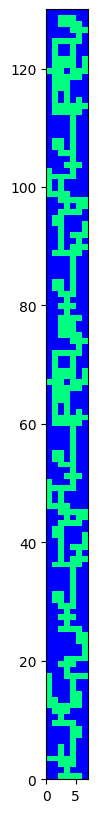

In [33]:
# this cell can be used to visualize part of the data

top_heigh_limit = 130
lower_heigh_limit = 0
rock_plot = np.zeros([CAVE_WIDENESS,top_heigh_limit - lower_heigh_limit + 1], dtype= bool)

rocks_in_plot = blocked_positions[ (blocked_positions[:,1] < top_heigh_limit) & (blocked_positions[:,1] >= lower_heigh_limit) ]
rocks_in_plot[:,1] -= lower_heigh_limit

for rocks in rocks_in_plot:
    rock_plot[ tuple(rocks) ] = True

plt.figure(figsize=(2,10))
plt.imshow(rock_plot.T, origin='lower', cmap="winter", extent=[0,CAVE_WIDENESS,lower_heigh_limit,top_heigh_limit]);
# plt.savefig('day16_rock_plot.png', dpi=200)

In [34]:
'''
The new number of falling rocks would take a ridicolously long amount of time to estimate the cell of the resulting tower. It would also require a high amount of memory containing all the fallen blocks. Part of this memory could be freed when all the width cells of the cave at a particular height are blocked, allowing to make that new height the new floor of the cave. However, adding a check to verify when these cells are blocked would also slow the program more

As the movements of the rock follow a pattern, and the order in which the rocks come from the ceiling are sequential, it can be assumed that at some point part of the structure of the tower will be repeated. If this pattern is found, it is possible to calculate what would be the height of the tower over any desired amount of falling rocks

After a number of rocks has fallen, the implemented program begins to look for a pattern by storing the position of all the rocks when a specific jet instruction (which determines rock movements) happens. The program will try to find those positions of the rock (considering a higher height) when that same jet instruction is repeated, hoping to find a match

TODO find if there is a number of rocks from which to start to look for a pattern (the implemented program choses an arbitrary high number function of the times the jet pattern has been repeated)
'''

N_FALLING_ROCKS = 1000000000000


n_second_pass_rocks = 0
for pass_idx in range(2): # one pass to find the pattern, another to check the extra missing heights (the ones at the beginning, before the pattern began)
    if(pass_idx == 0):
        maximum_number_falling_rocks = N_FALLING_ROCKS
    else:
        maximum_number_falling_rocks = n_second_pass_rocks
        blocked_positions = np.array([ [floor_width, -1] for floor_width in range(CAVE_WIDENESS) ]) # block the bottom of the field
    rock_reference_taken = False
    independent_jet_pattern_idx = 0
    super_independent_jet_pattern_idx = 0
    reference_independent_jet_pattern_idx = -1

    
    jet_pattern_idx = 0
    top_rock_height = -1
    for rock_idx in range(maximum_number_falling_rocks):
        rock_shape = RockShape(rock_idx % RockShape.N_SHAPES.value)
        
        leftmost_point = BEGINNING_WIDENESS
        lowmost_point = top_rock_height + BEGINNING_HEIGHT + 1
        if(rock_shape == RockShape.HORIZONTAL_LINE):
            rightmost_point = leftmost_point + 3

            while(True):
                jet = jet_pattern[jet_pattern_idx]
                independent_jet_pattern_idx += 1
                super_independent_jet_pattern_idx += 1
                jet_pattern_idx += 1
                if(jet_pattern_idx == pattern_length):
                    jet_pattern_idx = 0

                if(jet == ">"):
                    possible_new_rightmost_point = rightmost_point + 1 
                    if (possible_new_rightmost_point < CAVE_WIDENESS):
                        rightmost_combinations = [[possible_new_rightmost_point,lowmost_point]] # right of horizontal line
                        movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                        if(movement_is_possible == True):
                            rightmost_point = possible_new_rightmost_point
                            leftmost_point += 1

                elif(jet == "<"):
                    possible_new_leftmost_point = leftmost_point - 1 
                    if (possible_new_leftmost_point >= 0):
                        leftmost_combinations = [[possible_new_leftmost_point,lowmost_point]] # left of horizontal line
                        movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                        if(movement_is_possible == True):
                            leftmost_point = possible_new_leftmost_point
                            rightmost_point -= 1


                possible_new_lowmost_point = lowmost_point - 1
                lowermost_combinations = [[leftmost_point, possible_new_lowmost_point], [leftmost_point+1, possible_new_lowmost_point],[rightmost_point-1, possible_new_lowmost_point], [rightmost_point, possible_new_lowmost_point]]
                movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
                if(movement_is_possible == True):
                    lowmost_point = possible_new_lowmost_point
                else:
                    horizontal_line_position = [[leftmost_point,lowmost_point],[leftmost_point+1,lowmost_point],[rightmost_point-1,lowmost_point],[rightmost_point,lowmost_point]]
                    blocked_positions = np.vstack([blocked_positions, horizontal_line_position])
                    topmost_point = lowmost_point
                    if(topmost_point > top_rock_height):
                        top_rock_height = topmost_point
                    break


        elif(rock_shape == RockShape.CROSS):
            rightmost_point = leftmost_point + 2

            has_rock_stacked = False
            while(has_rock_stacked == False):
                jet = jet_pattern[jet_pattern_idx]
                independent_jet_pattern_idx += 1
                super_independent_jet_pattern_idx += 1
                jet_pattern_idx += 1
                if(jet_pattern_idx == pattern_length):
                    jet_pattern_idx = 0

                if(jet == ">"):
                    possible_new_rightmost_point = rightmost_point + 1 
                    if (possible_new_rightmost_point < CAVE_WIDENESS):
                        rightmost_combinations = [[possible_new_rightmost_point,lowmost_point+1],[rightmost_point,lowmost_point],[rightmost_point,lowmost_point+2]] # center-right, bottom, top of cross
                        movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                        if(movement_is_possible == True):
                            rightmost_point = possible_new_rightmost_point
                            leftmost_point += 1

                else:
                    possible_new_leftmost_point = leftmost_point - 1 
                    if (possible_new_leftmost_point >= 0):
                        leftmost_combinations = [[possible_new_leftmost_point,lowmost_point+1],[leftmost_point,lowmost_point],[leftmost_point,lowmost_point+2]] # center-right, bottom and top of cross
                        movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                        if(movement_is_possible == True):
                            leftmost_point = possible_new_leftmost_point
                            rightmost_point -= 1


                possible_new_lowmost_point = lowmost_point - 1
                lowermost_combinations = [[rightmost_point-1, possible_new_lowmost_point], [rightmost_point, lowmost_point], [leftmost_point, lowmost_point]] # bottom, center-right and center-left of cross
                movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
                if(movement_is_possible == True):
                    lowmost_point = possible_new_lowmost_point
                else:
                    cross_position = [[leftmost_point+1,lowmost_point],[leftmost_point,lowmost_point+1],[rightmost_point-1,lowmost_point+1],[rightmost_point,lowmost_point+1],[leftmost_point+1,lowmost_point+2]]
                    blocked_positions = np.vstack([blocked_positions, cross_position])
                    topmost_point = lowmost_point+2
                    if(topmost_point > top_rock_height):
                        top_rock_height = topmost_point
                    break
        

        elif(rock_shape == RockShape.LEFT_L):
            rightmost_point = leftmost_point + 2

            has_rock_stacked = False
            while(has_rock_stacked == False):
                jet = jet_pattern[jet_pattern_idx]
                independent_jet_pattern_idx += 1
                super_independent_jet_pattern_idx += 1
                jet_pattern_idx += 1
                if(jet_pattern_idx == pattern_length):
                    jet_pattern_idx = 0

                if(jet == ">"):
                    possible_new_rightmost_point = rightmost_point + 1 
                    if (possible_new_rightmost_point < CAVE_WIDENESS):
                        rightmost_combinations = [[possible_new_rightmost_point,lowmost_point],[possible_new_rightmost_point,lowmost_point+1],[possible_new_rightmost_point,lowmost_point+2]] # lower_right, center_right and top_right of left-L
                        movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                        if(movement_is_possible == True):
                            rightmost_point = possible_new_rightmost_point
                            leftmost_point += 1

                else:
                    possible_new_leftmost_point = leftmost_point - 1 
                    if (possible_new_leftmost_point >= 0):
                        leftmost_combinations = [[possible_new_leftmost_point,lowmost_point]] # lower left of left-L
                        movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                        if(movement_is_possible == True):
                            leftmost_point = possible_new_leftmost_point
                            rightmost_point -= 1


                possible_new_lowmost_point = lowmost_point - 1
                lowermost_combinations = [[leftmost_point, possible_new_lowmost_point], [leftmost_point+1, possible_new_lowmost_point], [rightmost_point, possible_new_lowmost_point]] # left, center and lower_right of left-L
                movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
                if(movement_is_possible == True):
                    lowmost_point = possible_new_lowmost_point
                else:
                    left_L_position = [[leftmost_point,lowmost_point],[leftmost_point+1,lowmost_point],[rightmost_point,lowmost_point],[rightmost_point,lowmost_point+1],[rightmost_point,lowmost_point+2]]
                    blocked_positions = np.vstack([blocked_positions, left_L_position])

                    topmost_point = lowmost_point + 2
                    if(topmost_point > top_rock_height):
                        top_rock_height = topmost_point
                    break


        elif(rock_shape == RockShape.VERTICAL_LINE):
            rightmost_point = leftmost_point

            has_rock_stacked = False
            while(has_rock_stacked == False):
                jet = jet_pattern[jet_pattern_idx]
                independent_jet_pattern_idx += 1
                super_independent_jet_pattern_idx += 1
                jet_pattern_idx += 1
                if(jet_pattern_idx == pattern_length):
                    jet_pattern_idx = 0

                if(jet == ">"):
                    possible_new_rightmost_point = rightmost_point + 1 
                    if (possible_new_rightmost_point < CAVE_WIDENESS):
                        rightmost_combinations = [[possible_new_rightmost_point,lowmost_point],[possible_new_rightmost_point,lowmost_point+1],[possible_new_rightmost_point,lowmost_point+2],[possible_new_rightmost_point,lowmost_point+3]] # top, centers and bottom of vertical line
                        movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                        if(movement_is_possible == True):
                            rightmost_point = possible_new_rightmost_point
                            leftmost_point += 1

                else:
                    possible_new_leftmost_point = leftmost_point - 1 
                    if (possible_new_leftmost_point >= 0):
                        leftmost_combinations = [[possible_new_leftmost_point,lowmost_point],[possible_new_leftmost_point,lowmost_point+1],[possible_new_leftmost_point,lowmost_point+2],[possible_new_leftmost_point,lowmost_point+3]] # top, centers and bottom of vertical line
                        movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                        if(movement_is_possible == True):
                            leftmost_point = possible_new_leftmost_point
                            rightmost_point -= 1


                possible_new_lowmost_point = lowmost_point - 1
                lowermost_combinations = [[leftmost_point, possible_new_lowmost_point]] # bottom of vertical line
                movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
                if(movement_is_possible == True):
                    lowmost_point = possible_new_lowmost_point
                else:
                    vertical_line_final_position = [[leftmost_point,lowmost_point],[leftmost_point,lowmost_point+1],[leftmost_point,lowmost_point+2],[leftmost_point,lowmost_point+3]]
                    blocked_positions = np.vstack([blocked_positions, vertical_line_final_position])

                    topmost_point = lowmost_point + 3
                    if(topmost_point > top_rock_height):
                        top_rock_height = topmost_point
                    break

        elif(rock_shape == RockShape.SQUARE):
            rightmost_point = leftmost_point + 1

            has_rock_stacked = False
            while(has_rock_stacked == False):
                jet = jet_pattern[jet_pattern_idx]
                independent_jet_pattern_idx += 1
                super_independent_jet_pattern_idx += 1
                jet_pattern_idx += 1
                if(jet_pattern_idx == pattern_length):
                    jet_pattern_idx = 0

                if(jet == ">"):
                    possible_new_rightmost_point = rightmost_point + 1 
                    if (possible_new_rightmost_point < CAVE_WIDENESS):
                        rightmost_combinations = [[possible_new_rightmost_point,lowmost_point],[possible_new_rightmost_point,lowmost_point+1]] # bottom-right and top-right of square
                        movement_is_possible = CheckRockBlockedness(rightmost_combinations)
                        if(movement_is_possible == True):
                            rightmost_point = possible_new_rightmost_point
                            leftmost_point += 1

                else:
                    possible_new_leftmost_point = leftmost_point - 1 
                    if (possible_new_leftmost_point >= 0):
                        leftmost_combinations = [[possible_new_leftmost_point,lowmost_point],[possible_new_leftmost_point,lowmost_point+1]] # bottom-left and top-left of square
                        movement_is_possible = CheckRockBlockedness(leftmost_combinations) 
                        if(movement_is_possible == True):
                            leftmost_point = possible_new_leftmost_point
                            rightmost_point -= 1


                possible_new_lowmost_point = lowmost_point - 1
                lowermost_combinations = [[leftmost_point, possible_new_lowmost_point],[rightmost_point, possible_new_lowmost_point]] # bottom-left and bottom-right of square
                movement_is_possible = CheckRockBlockedness(lowermost_combinations)        
                if(movement_is_possible == True):
                    lowmost_point = possible_new_lowmost_point
                else:
                    square_final_position = [[leftmost_point,lowmost_point],[leftmost_point,lowmost_point+1],[rightmost_point,lowmost_point],[rightmost_point,lowmost_point+1]]
                    blocked_positions = np.vstack([blocked_positions, square_final_position])

                    topmost_point = lowmost_point + 1
                    if(topmost_point > top_rock_height):
                        top_rock_height = topmost_point
                    break
                

            # how can one know when the repetition begins?
            if(rock_reference_taken == False and super_independent_jet_pattern_idx > pattern_length and rock_idx > 200):
                reference_rock_list = np.array([np.array(horizontal_line_position), np.array(cross_position), np.array(left_L_position), np.array(vertical_line_final_position), np.array(square_final_position)], dtype=object)
                for idx in range(len(reference_rock_list)):
                    reference_rock_list[idx][:,1] -= top_rock_height
                reference_independent_jet_pattern_idx = independent_jet_pattern_idx
                reference_rock_idx = rock_idx
                reference_top_rock_height = top_rock_height
                rock_reference_taken = True

            elif(reference_independent_jet_pattern_idx == independent_jet_pattern_idx ):
                rock_to_compare_list = np.array([np.array(horizontal_line_position), np.array(cross_position), np.array(left_L_position), np.array(vertical_line_final_position), np.array(square_final_position)], dtype=object)
                for idx in range(len(reference_rock_list)):
                    rock_to_compare_list[idx][:,1] -= top_rock_height
                    
                all_rocks_are_repeated = True
                for reference_rock, rock_to_compare in zip(reference_rock_list, rock_to_compare_list):
                    if( not ( np.all(reference_rock[:,1] == rock_to_compare[:,1]) and np.all(reference_rock[:,0] == rock_to_compare[:,0]) ) ):
                        all_rocks_are_repeated = False
                        break

                if(all_rocks_are_repeated == True):
                    repeated_rock_patterns_height = top_rock_height - reference_top_rock_height
                    n_rocks_between_repeated_rock_patterns = rock_idx - reference_rock_idx

                    n_repeated_rock_patterns = int(N_FALLING_ROCKS / n_rocks_between_repeated_rock_patterns)
                    n_second_pass_rocks = N_FALLING_ROCKS - n_repeated_rock_patterns*n_rocks_between_repeated_rock_patterns

                    break

            independent_jet_pattern_idx = 0



total_tower_height = n_repeated_rock_patterns * repeated_rock_patterns_height + top_rock_height + 1

print("After", N_FALLING_ROCKS, "falling rocks, the tower will be", total_tower_height, "units tall")

After 1000000000000 falling rocks, the tower will be 5299999999813 units tall


# [Day 18: Boiling Boulders](https://adventofcode.com/2022/day/18)
**First Part:** Count sides of cubes not connected to other cubes

**Second Part:** Count sides of cubes not connected to other cubes, but ignoring empty inside spaces

In [35]:
'''
TODO the code could benefit a lot from more numpy notation instead of loops. More formating is needed
'''

with open(file_names[17]) as file:
    lines18 = file.read().splitlines()
    while(lines18[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines18.pop()
    
maximum_x = 0
maximum_y = 0
maximum_z = 0
for line in lines18:
    proposed_x, proposed_y, proposed_z = list(map(int,line.split(",")))
    if(proposed_x>maximum_x):
        maximum_x = proposed_x
    if(proposed_y>maximum_y):
        maximum_y = proposed_y
    if(proposed_z>maximum_z):
        maximum_z = proposed_z

EXTRA_N = 2
super_ball = np.zeros([maximum_x+1+EXTRA_N,maximum_y+1+EXTRA_N,maximum_z+1+EXTRA_N], dtype=int)
for line in lines18:
    super_ball[tuple(np.array(list(map(int,line.split(",")))) +1)] = 1

def CheckSides(x_base,y_base,z_base):
    score = 6
    y = y_base
    z = z_base
    for x in [x_base-1,x_base+1]:
        score -= super_ball[(x,y,z)]

    x = x_base
    for y in [y_base-1,y_base+1]:
        score -= super_ball[(x,y,z)]

    y = y_base
    for z in [z_base-1,z_base+1]:
        score -= super_ball[(x,y,z)]
    return score


surface_area = 0
for x, y, z in np.ndindex(super_ball.shape):
    if super_ball[x,y,z] == 1:
        added_sides = CheckSides(x,y,z)
        surface_area += added_sides
    
print("The total surface area is", surface_area)

The total surface area is 64


In [36]:
'''
TODO the code could benefit a lot from more numpy notation instead of loops. More formating is needed
'''

def CheckSidesReversed(x_base,y_base,z_base):
    score = -6

    y = y_base
    z = z_base
    for x in [x_base-1,x_base+1]:
        score += (1- super_ball[(x,y,z)])

    x = x_base
    for y in [y_base-1,y_base+1]:
        score += (1- super_ball[(x,y,z)])

    y = y_base
    for z in [z_base-1,z_base+1]:
        score += (1- super_ball[(x,y,z)])
    return score

def IsItAExtremeWithinItsAxis(x,y,z):
    idxmax = np.where(super_ball[:,y,z] == 1)[0]
    if (len(idxmax) == 0):
         return True
    else:
        idxmax = np.max(idxmax)

    idymax = np.where(super_ball[x,:,z] == 1)[0]
    if (len(idymax) == 0):
        return True
    else:
        idymax = np.max(idymax)

    idzmax = np.where(super_ball[x,y,:] == 1)[0]
    if (len(idzmax) == 0):
        return True
    else:
        idzmax = np.max(idzmax)

    idxmin = np.where(super_ball[:,y,z] == 1)[0]
    if (len(idxmin) == 0):
        return True
    else:
        idxmin = np.min(idxmin)

    idymin = np.where(super_ball[x,:,z] == 1)[0]
    if (len(idymin) == 0):
        return True
    else:
        idymin = np.min(idymin)

    idzmin = np.where(super_ball[x,y,:] == 1)[0]
    if (len(idzmin) == 0):
        return True
    else:
        idzmin = np.min(idzmin)

    if(x > idxmax or y > idymax or z > idzmax or x < idxmin or y < idymin or z < idzmin):
        return True

    return False


def IsItInAnAirBubble(x,y,z):
    visited_list = [[x+1,y,z],[x-1,y,z],[x,y+1,z],[x,y-1,z],[x,y,z+1],[x,y,z-1]]
    air_bubble_neighbours = [[x+1,y,z],[x-1,y,z],[x,y+1,z],[x,y-1,z],[x,y,z+1],[x,y,z-1]]
    while(len(air_bubble_neighbours) != 0):
        test_x,test_y,test_z = air_bubble_neighbours.pop(0)
        if(super_ball[(test_x,test_y,test_z)] == 1):
            continue
        elif(IsItAExtremeWithinItsAxis(test_x,test_y,test_z) == True):
            return False
        else:
            for proposal in [[test_x+1,test_y,test_z],[test_x-1,test_y,test_z],[test_x,test_y+1,test_z],[test_x,test_y-1,test_z],[test_x,test_y,test_z+1],[test_x,test_y,test_z-1]]:
                if(proposal not in visited_list):
                    air_bubble_neighbours += [proposal]
                    visited_list += [proposal]
    return True


surface_area = 0
for x, y, z in np.ndindex(super_ball.shape):
    if super_ball[x,y,z] == 1:
        
        added_sides = CheckSides(x,y,z)
        surface_area += added_sides
    else:
        if(IsItAExtremeWithinItsAxis(x,y,z) == False):
            if(IsItInAnAirBubble(x,y,z) == True):
                added_sides = CheckSidesReversed(x,y,z)
                surface_area += added_sides

print("The exterior surface area is", total_score)

The exterior surface area is 12


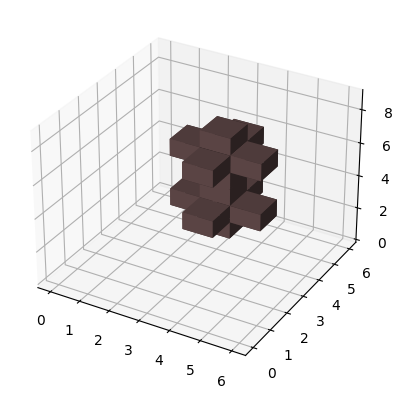

In [37]:
# %matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

alpha = 1
cube_colors = np.ones([super_ball.shape[0],super_ball.shape[1],super_ball.shape[2],4]) * [0.4,0.3,0.3,1] # red, green, blue, alpha (all normalized)
ax.voxels(super_ball, facecolors=cube_colors);

In [38]:
%matplotlib inline

# [Day 19: Not Enough Minerals](https://adventofcode.com/2022/day/19)
**First Part:** TODO

**Second Part:** TODO

# [Day 20: Grove Positioning System](https://adventofcode.com/2022/day/20)
**First Part:** Decode a file with mixing operations

**Second Part:** Decode a file after applying a decryption key by repeating mixing operations

In [39]:
'''
Note that the Python takes into account negatives as well when using the modulo operator (it implements the flored modulo) e.g. -1 % 7 = -7
'''

BASE_DECRYPTING_NUMBER = 0 # although not explicitly stated, there has to be only one number with this value in the file
DECRYPTING_MOVEMENT_1 = 1000
DECRYPTING_MOVEMENT_2 = 2000
DECRYPTING_MOVEMENT_3 = 3000

with open(file_names[19]) as file:
    lines20 = file.read().splitlines()
    while(lines20[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines20.pop()


encrypted_file = list(map(int,lines20))
encryption_length = len(encrypted_file)
unencrypted_line_indexes = list(range(encryption_length)) # stores the original indexes of the file
encryption_movement_limit = encryption_length -1 # after this index position, the file wraps


for encrypted_file_idx in range(encryption_length):
    idx_list_idx = unencrypted_line_indexes.index(encrypted_file_idx) # get the index of the element in the encrypted file that is being processed, so it can show its current index in the variable that stores all initial indexes
    suggested_movement = encrypted_file[encrypted_file_idx]
    if(suggested_movement < 0): 
        # moves to the left
        movement = suggested_movement % - encryption_movement_limit 

        if((movement+idx_list_idx) <= 0):
            # wraps to the left, so the movement has to become positive
            movement = suggested_movement % encryption_movement_limit
            unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:idx_list_idx+1+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement+1:]
        else:
            unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:]

    else:
        # moves to the right
        movement = suggested_movement % encryption_movement_limit 
        if((movement+idx_list_idx) > encryption_movement_limit):
            # wraps to the right, so the movement has to become negative
            movement = movement % -encryption_movement_limit
            unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:]

        else:
            unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:idx_list_idx+1+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement+1:]


original_base_decrypting_number_index = encrypted_file.index(BASE_DECRYPTING_NUMBER)
new_base_decrypting_number_index = unencrypted_line_indexes.index(original_base_decrypting_number_index)

decrypting_movement_1 = (new_base_decrypting_number_index + DECRYPTING_MOVEMENT_1 % encryption_length) % encryption_length
decrypting_movement_2 = (new_base_decrypting_number_index + DECRYPTING_MOVEMENT_2 % encryption_length) % encryption_length
decrypting_movement_3 = (new_base_decrypting_number_index + DECRYPTING_MOVEMENT_3 % encryption_length) % encryption_length

coordinate_part_1 = encrypted_file[unencrypted_line_indexes[decrypting_movement_1]]
coordinate_part_2 = encrypted_file[unencrypted_line_indexes[decrypting_movement_2]]
coordinate_part_3 = encrypted_file[unencrypted_line_indexes[decrypting_movement_3]]

grove_coordinates = coordinate_part_1 + coordinate_part_2 + coordinate_part_3
print("The grove are coordinates are", grove_coordinates)

The grove are coordinates are 3


In [40]:
'''
This is basically the same code as the previous part, bar from being repeated a couple times and adding a multiplication for the encryption key
'''

ENCRYPTION_KEY = 811589153
N_MIXES = 10


for idx in range(encryption_length):
    encrypted_file[idx] *= ENCRYPTION_KEY

unencrypted_line_indexes = list(range(encryption_length)) # stores the original indexes of the file

for _ in range(N_MIXES):
    for encrypted_file_idx in range(encryption_length):
        idx_list_idx = unencrypted_line_indexes.index(encrypted_file_idx) # get the index of the element in the encrypted file that is being processed, so it can show its current index in the variable that stores all initial indexes
        suggested_movement = encrypted_file[encrypted_file_idx]
        if(suggested_movement < 0): 
            # moves to the left
            movement = suggested_movement % - encryption_movement_limit 

            if((movement+idx_list_idx) <= 0):
                # wraps to the left, so the movement has to become positive
                movement = suggested_movement % encryption_movement_limit
                unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:idx_list_idx+1+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement+1:]
            else:
                unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:]

        else:
            # moves to the right
            movement = suggested_movement % encryption_movement_limit 
            if((movement+idx_list_idx) > encryption_movement_limit):
                # wraps to the right, so the movement has to become negative
                movement = movement % -encryption_movement_limit
                unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:]

            else:
                unencrypted_line_indexes = unencrypted_line_indexes[:idx_list_idx] + unencrypted_line_indexes[idx_list_idx+1:idx_list_idx+1+movement] + [unencrypted_line_indexes[idx_list_idx]] + unencrypted_line_indexes[idx_list_idx+movement+1:]


original_base_decrypting_number_index = encrypted_file.index(BASE_DECRYPTING_NUMBER)
new_base_decrypting_number_index = unencrypted_line_indexes.index(original_base_decrypting_number_index)

decrypting_movement_1 = (new_base_decrypting_number_index + DECRYPTING_MOVEMENT_1 % encryption_length) % encryption_length
decrypting_movement_2 = (new_base_decrypting_number_index + DECRYPTING_MOVEMENT_2 % encryption_length) % encryption_length
decrypting_movement_3 = (new_base_decrypting_number_index + DECRYPTING_MOVEMENT_3 % encryption_length) % encryption_length

coordinate_part_1 = encrypted_file[unencrypted_line_indexes[decrypting_movement_1]]
coordinate_part_2 = encrypted_file[unencrypted_line_indexes[decrypting_movement_2]]
coordinate_part_3 = encrypted_file[unencrypted_line_indexes[decrypting_movement_3]]

grove_coordinates = coordinate_part_1 + coordinate_part_2 + coordinate_part_3
print("The actual grove are coordinates are", grove_coordinates)

The actual grove are coordinates are 1623178306


# [Day 21: Monkey Math](https://adventofcode.com/2022/day/21)
**First Part:** Predict the number, result of many math operations, that will be yelled by a monkey

**Second Part:** Find the number that after many math operations matches the number that will be yelled by a monkey


In [41]:
'''
It was not explicitly stated, by the base numbers are not negative and are integers. This allow to use the string function isnumeric()

The program could benefit from deleting the lines that have been processed, instead of just adding conditions to not check them twice
'''

ROOT_MONKEY_NAME = "root"

def MonkeyMathOperation(leftmost_number, rightmost_number, operation_type):
    if(operation_type == "*"):
        math_result = leftmost_number * rightmost_number
    elif(operation_type == "/"):
        math_result = leftmost_number // rightmost_number
    elif(operation_type == "+"):
        math_result = leftmost_number + rightmost_number
    elif(operation_type == "-"):
        math_result = leftmost_number - rightmost_number
    else:
        print("Wrong math operator received")
        math_result = -1

    return math_result


with open(file_names[20]) as file:
    stacked_lines = file.read()
    lines21 = stacked_lines.splitlines()
    while(lines21[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines21.pop()
        stacked_lines = stacked_lines[:-1]

    
for line in lines21:
    split_line = line.split(" ")
    if(len(split_line)==2): # lines that fulfill this condition are the ones that do not contain a math operation but numbers
        monkey_name = split_line[0][:-1]
        yelled_number = split_line[1]
        stacked_lines = stacked_lines.replace(monkey_name, yelled_number)

loop_got_stuck = False # variable use to avoid infinites loops, something that should never become happen 
while(loop_got_stuck == False):

    root_line = stacked_lines[stacked_lines.find(ROOT_MONKEY_NAME):].splitlines()[0].split(" ")
    if (root_line[1].isnumeric() and root_line[3].isnumeric()):
        break

    processed_lines = stacked_lines.splitlines()
    loop_got_stuck = True # will become false is the loop does not get stuck
    for line in processed_lines:
        split_line = line.split(" ")
        monkey_name = split_line[0][:-1]
        if(len(split_line)>2 and (not monkey_name.isnumeric())):
            if (split_line[1].isnumeric() and split_line[3].isnumeric()):
                
                math_result = MonkeyMathOperation(int(split_line[1]), int(split_line[3]), split_line[2])
                stacked_lines = stacked_lines.replace(monkey_name, str(math_result))
                loop_got_stuck = False

if(loop_got_stuck == True):
    print("This should never happen: the program ended in an infinite loop")
else:
    math_result = MonkeyMathOperation(int(root_line[1]), int(root_line[3]), root_line[2])
    print("The monkey named", ROOT_MONKEY_NAME,  "will yell", math_result)

The monkey named root will yell 152


In [42]:
'''
It was not explicitly stated, but it seems that all yelled numbers (numbers that do not require math operations) are used only once by one individual monkey. This means that is possible to find one of the numbers yelled by the root monkey in the same way that the previous cell did, as there is only one unknown number. Also, this means that the other number can be found just reversing the operations that would normally give the second number to the root monkey

Again, the program could benefit from deleting the lines that have been processed, instead of just adding conditions to not check them twice
'''

NAME_CORRESPONDING_TO_YOU = "humn"

with open(file_names[20]) as file:
    stacked_lines = file.read()
    lines21 = stacked_lines.splitlines()
    while(lines21[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines21.pop()
        stacked_lines = stacked_lines[:-1]


for line in lines21:
    split_line = line.split(" ")
    if(len(split_line)==2): # lines that fulfill this condition are the ones that do not contain a math operation but numbers
        monkey_name = split_line[0][:-1]

        if(monkey_name != NAME_CORRESPONDING_TO_YOU):
            yelled_number = split_line[1]
            stacked_lines = stacked_lines.replace(monkey_name, yelled_number)

loop_got_stuck = False # in this case, the loop has to get stuck before leaving it
while(loop_got_stuck == False):

    processed_lines = stacked_lines.splitlines()
    loop_got_stuck = True
    for line in processed_lines:
        split_line = line.split(" ")
        monkey_name = split_line[0][:-1]
        if(len(split_line)>2 and (not monkey_name.isnumeric())):
            if (split_line[1].isnumeric() and split_line[3].isnumeric()):
                
                math_result = MonkeyMathOperation(int(split_line[1]), int(split_line[3]), split_line[2])

                if (monkey_name != ROOT_MONKEY_NAME):
                    stacked_lines = stacked_lines.replace(monkey_name, str(math_result))
                loop_got_stuck = False


# 
root_line = stacked_lines[stacked_lines.find(ROOT_MONKEY_NAME):].splitlines()[0].split(" ")
if (root_line[1].isnumeric() == True):
    upper_math_result = root_line[3]
    lower_monkey_name = root_line[1]
elif(root_line[3].isnumeric() == True):
    upper_math_result = root_line[3]
    lower_monkey_name = root_line[1]
else:
    print("This should never happen: the root monkey did not find one number")


loop_got_stuck = False
base_monkey_value_found = False
while(loop_got_stuck == False and base_monkey_value_found == False ):

    processed_lines = stacked_lines.splitlines()
    loop_got_stuck = True
    for line in processed_lines:
        split_line = line.split(" ")
        monkey_name = split_line[0][:-1]

        if(lower_monkey_name != monkey_name):
            continue

        if (split_line[1].isnumeric()):
            lower_monkey_name = split_line[3]
            complementary_math_result = split_line[1]
            lower_monkey_on_left_side = False
        elif (split_line[3].isnumeric()):
            lower_monkey_name = split_line[1]
            complementary_math_result = split_line[3]
            lower_monkey_on_left_side = True


        if(split_line[2] == "*"):
            math_result = int(upper_math_result) // int(complementary_math_result)
        elif(split_line[2] == "/"):
            math_result = int(upper_math_result) * int(complementary_math_result)
        elif(split_line[2] == "-"):
            if(lower_monkey_on_left_side == False):
                math_result = int(complementary_math_result) - int(upper_math_result)
            else:
                math_result = int(upper_math_result) + int(complementary_math_result)
        elif(split_line[2] == "+"):
            math_result = int(upper_math_result) - int(complementary_math_result)
        else:
            print("Wrong math operator received")
            loop_got_stuck = True
            break

        stacked_lines = stacked_lines.replace(monkey_name, str(math_result))
        upper_math_result = str(math_result)

        loop_got_stuck = False
        if(lower_monkey_name == "humn"):
            base_monkey_value_found = True
            break
        
        

if(loop_got_stuck == True):
    print("This should never happen: Either the the program ended in an infinite loop or there was a math operator error")
else:
    print("The number to be yelled is", math_result)

The number to be yelled is 301


# [Day 22: Monkey Map](https://adventofcode.com/2022/day/22)
**First Part:** Follow the given path, taking into account wrapping rules

**Second Part:** Follow the given path, taking into account new 3D wrapping rules


In [43]:
class Orientation(enum.IntEnum):
    LOWER_LIMIT = -1
    RIGHT = 0
    DOWN = 1
    LEFT = 2
    UP = 3
    UPPER_LIMIT = 4


NO_PATH = " "
SOLID_WALL = "#"
OPEN_TILE = "."
CLOCKWISE_INSTRUCTION = "R"
COUNTERCLOCKWISE_INSTRUCTION = "L"


with open(file_names[21]) as file:
    stacked_lines = file.read()
    lines22 = stacked_lines.splitlines()
    while(lines22[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines22.pop()



steps_instructions = lines22[-1]
maze = lines22[:-2]
n_rows = len(maze)
n_cols = 0
for line in maze:
    possible_n_cols = len(line)
    if(possible_n_cols > n_cols):
        n_cols = possible_n_cols

wrap_points_correspondences_col_right = {}
wrap_points_correspondences_col_left = {}
blocked_paths = []

for row_n in range(n_rows):
    n_cols_in_row = len(maze[row_n])

    if(maze[row_n][0] == NO_PATH):
        possible_wrap_col = -1
    elif(maze[row_n][0] == SOLID_WALL):
        blocked_paths.append([row_n,0])
        possible_wrap_col = 0
    else:
        possible_wrap_col = 0

    for col_n in range(1,n_cols_in_row-1):
        
        if(maze[row_n][col_n] == NO_PATH):
            continue
        
        else:
            if(maze[row_n][col_n] == SOLID_WALL):
                blocked_paths.append([row_n,col_n])
                
            if(possible_wrap_col == -1):
                possible_wrap_col = col_n

    if(maze[row_n][n_cols_in_row-1] == SOLID_WALL):
        blocked_paths.append([row_n,n_cols_in_row-1])
    
    wrap_points_correspondences_col_left[str([row_n,possible_wrap_col])] = [row_n,n_cols_in_row-1]
    wrap_points_correspondences_col_right[str([row_n,n_cols_in_row-1])] = [row_n,possible_wrap_col]


wrap_points_correspondences_row_up = {}
wrap_points_correspondences_row_down = {}
for col_n in range(n_cols):

    if(col_n >= len(maze[0])):
        possible_wrap_row = -1
        beginning_has_been_found = False
    elif(maze[0][col_n] == NO_PATH):
        possible_wrap_row = -1
        beginning_has_been_found = False
    elif(maze[0][col_n] == SOLID_WALL):
        blocked_paths.append([0,col_n])
        possible_wrap_row = 0
        beginning_has_been_found = True
    else:
        possible_wrap_row = 0
        beginning_has_been_found = True

    for row_n in range(1,n_rows):

        if(col_n >= len(maze[row_n])):
            if(beginning_has_been_found == True):
                if(maze[row_n-1][col_n] == SOLID_WALL):
                    blocked_paths.append([row_n-1,col_n])
          
                wrap_points_correspondences_row_down[str([row_n-1,col_n])] = [possible_wrap_row,col_n]
                wrap_points_correspondences_row_up[str([possible_wrap_row,col_n])] = [row_n-1,col_n]
                possible_wrap_row = -1
                beginning_has_been_found = False
                break
            else:
                continue

        if(maze[row_n][col_n] == NO_PATH):

            if(beginning_has_been_found == True):
                if(maze[row_n-1][col_n] == SOLID_WALL):
                    blocked_paths.append([row_n-1,col_n])
          
                wrap_points_correspondences_row_down[str([row_n-1,col_n])] = [possible_wrap_row,col_n]
                wrap_points_correspondences_row_up[str([possible_wrap_row,col_n])] = [row_n-1,col_n]
                possible_wrap_row = -1
                break
            
        
        else:
            if(maze[row_n][col_n] == SOLID_WALL):
                blocked_paths.append([row_n,col_n])
                
            if(beginning_has_been_found == False and possible_wrap_row == -1):
                    possible_wrap_row = row_n
                    beginning_has_been_found = True
        
        

    if(possible_wrap_row != -1):
        wrap_points_correspondences_row_down[str([row_n,col_n])] = [possible_wrap_row,col_n]
        wrap_points_correspondences_row_up[str([possible_wrap_row,col_n])] = [row_n,col_n]


maze_map = np.zeros([n_rows,n_cols]) # variable only used to keep track of the path in order to plot it
next_orientation = Orientation.RIGHT
position = [0, maze[0].find(OPEN_TILE)]
end_following_path = False
while(end_following_path == False):
    current_orientation = next_orientation

    clockwise_instruction_pos = steps_instructions.find(CLOCKWISE_INSTRUCTION)
    counterclockwise_instruction_pos = steps_instructions.find(COUNTERCLOCKWISE_INSTRUCTION)

    if(counterclockwise_instruction_pos == -1 and clockwise_instruction_pos == -1):
        end_following_path = True
        n_steps = int(steps_instructions)
        next_orientation = current_orientation
    else:
        if(counterclockwise_instruction_pos == -1):
            counterclockwise_instruction_pos = clockwise_instruction_pos + 1 # force it to fulfill the conditions below
        elif(clockwise_instruction_pos == -1):
            clockwise_instruction_pos = counterclockwise_instruction_pos + 1 # force it to fulfill the conditions below

        if(clockwise_instruction_pos < counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:clockwise_instruction_pos])
            steps_instructions = steps_instructions[clockwise_instruction_pos+1:]
            next_orientation = current_orientation + 1

        elif(clockwise_instruction_pos > counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:counterclockwise_instruction_pos])
            steps_instructions = steps_instructions[counterclockwise_instruction_pos+1:]
            next_orientation = current_orientation - 1

    possible_next_position = position.copy()
    if(current_orientation == Orientation.UP):
        for _ in range(n_steps):
            possible_next_position[0] -= 1
            if(str(position) in wrap_points_correspondences_row_up):
                possible_next_position = wrap_points_correspondences_row_up[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    elif(current_orientation == Orientation.RIGHT):
        for _ in range(n_steps):
            possible_next_position[1] += 1
            if(str(position) in wrap_points_correspondences_col_right):
                possible_next_position = wrap_points_correspondences_col_right[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    elif(current_orientation == Orientation.DOWN):
        for _ in range(n_steps):
            possible_next_position[0] += 1
            if(str(position) in wrap_points_correspondences_row_down):
                possible_next_position = wrap_points_correspondences_row_down[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    elif(current_orientation == Orientation.LEFT):
        for _ in range(n_steps):
            possible_next_position[1] -= 1
            if(str(position) in wrap_points_correspondences_col_left):
                possible_next_position = wrap_points_correspondences_col_left[str(position)].copy()
            if(possible_next_position not in blocked_paths):
                position = possible_next_position.copy()
                maze_map[tuple(position)] = 10
            else:
                break

    
    if(next_orientation == Orientation.LOWER_LIMIT):
        next_orientation = Orientation.UPPER_LIMIT - 1
    elif(next_orientation == Orientation.UPPER_LIMIT):
        next_orientation = Orientation.LOWER_LIMIT + 1



position_1_based = position.copy()
position_1_based[0] += 1
position_1_based[1] += 1
password = 1000*position_1_based[0] + position_1_based[1]*4 + current_orientation
print("The final position is row {}, column {} and oriented {}, which gives the password {}".format(position_1_based[0], position_1_based[1], Orientation(current_orientation).name.lower(), password) )

The final position is row 6, column 8 and oriented right, which gives the password 6032


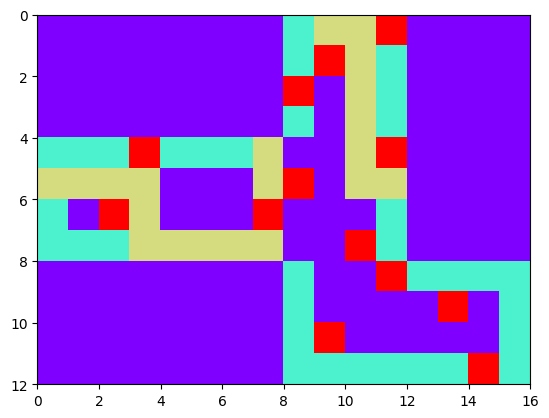

In [44]:
# TODO make the colors nicer, although it looks decent when using the non-example input file

# the evals are used to avoid parsing the string
maze_map_to_plot = maze_map.copy()
for wrap_point in wrap_points_correspondences_col_right.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_down.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_col_left.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_up.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for blocked_cell in blocked_paths:
    maze_map_to_plot[tuple(blocked_cell)] = 15
    
plt.imshow(maze_map_to_plot, cmap="rainbow", extent=[0,n_cols,n_rows,0]); # it is more practical to use a imshow than to show text, as the input that is not from the example is really long. It could be nice to have the text file scaled and displayed

In [45]:
'''
This cell maintained the same structure as the previous part, with some notation improvements. Now, the wrapping point variables are expanded to cover all sides of the cube. However, these variables that determine the wrapping points of the cube are harcoded for both available files. TODO think of a general code that could assign those wrapping points automatically, the example file and the non-example file gave different cube structures
'''

wrap_points_correspondences_right = {}
wrap_points_correspondences_left = {}
wrap_points_correspondences_up = {}
wrap_points_correspondences_down = {}
wrap_points_orientations_right = {}
wrap_points_orientations_left = {}
wrap_points_orientations_up = {}
wrap_points_orientations_down = {}

if(len(lines22) == 14): # if it is the example file
    CUBE_DIMENSIONS = 4

    # first row of cubes
    col_begin = CUBE_DIMENSIONS*2
    row_begin = 0
    row_dest = CUBE_DIMENSIONS
    col_dest = CUBE_DIMENSIONS
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest + movement_step] # appears top
        wrap_points_correspondences_left[str(incoming)] = destination 
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.RIGHT

    col_begin = CUBE_DIMENSIONS*3-1
    row_begin = 0
    row_dest = CUBE_DIMENSIONS*4 - 1
    col_dest = CUBE_DIMENSIONS*3 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest - movement_step, col_dest] # appears right
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_left[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.LEFT
        wrap_points_orientations_left[str(destination)] = Orientation.LEFT


    # second row of cubes 
    col_begin = 0
    row_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*3-1
    col_dest = CUBE_DIMENSIONS*4-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest - movement_step] # appears down
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.RIGHT

    col_begin = CUBE_DIMENSIONS*3-1
    row_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*2
    col_dest = CUBE_DIMENSIONS*4 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest, col_dest - movement_step] # appears top
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.LEFT


    # third row of cubes (only leftmost)
    col_begin = CUBE_DIMENSIONS*2
    row_begin = CUBE_DIMENSIONS*2
    row_dest = CUBE_DIMENSIONS*2-1
    col_dest = CUBE_DIMENSIONS*2-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest - movement_step] # appears down
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.RIGHT

    # first column of cubes
    col_begin = 0
    row_begin = CUBE_DIMENSIONS
    row_dest = 0
    col_dest = CUBE_DIMENSIONS*3-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin, col_begin + movement_step] # goes top
        destination = [row_dest, col_dest - movement_step] # appears top
        wrap_points_correspondences_up[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_up[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.DOWN

    col_begin = 0
    row_begin = CUBE_DIMENSIONS*2-1
    row_dest = CUBE_DIMENSIONS*3-1
    col_dest = CUBE_DIMENSIONS*3-1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin, col_begin + movement_step] # goes bottom
        destination = [row_dest, col_dest - movement_step] # appears bottom
        wrap_points_correspondences_down[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_down[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.UP



else: 
    CUBE_DIMENSIONS = 50

    # first row of cubes
    row_begin = 0
    col_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*3-1
    col_dest = 0
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest - movement_step, col_dest] # appears left
        wrap_points_correspondences_left[str(incoming)] = destination 
        wrap_points_correspondences_left[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.RIGHT
        wrap_points_orientations_left[str(destination)] = Orientation.RIGHT

    row_begin = 0
    col_begin = CUBE_DIMENSIONS*3-1
    row_dest = CUBE_DIMENSIONS*3 - 1
    col_dest = CUBE_DIMENSIONS*2 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest - movement_step, col_dest] # appears right
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_right[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.LEFT
        wrap_points_orientations_right[str(destination)] = Orientation.LEFT

    # second row of cubes
    row_begin = CUBE_DIMENSIONS
    col_begin = CUBE_DIMENSIONS
    row_dest = CUBE_DIMENSIONS*2
    col_dest = 0
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest + movement_step] # appears top
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.RIGHT

    row_begin = CUBE_DIMENSIONS
    col_begin = CUBE_DIMENSIONS*2-1
    row_dest = CUBE_DIMENSIONS - 1
    col_dest = CUBE_DIMENSIONS*2
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest, col_dest + movement_step] # appears down
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.LEFT

    
    # fourth row of cubes
    row_begin = CUBE_DIMENSIONS*3
    col_begin = 0
    row_dest = 0
    col_dest = CUBE_DIMENSIONS*2 - 1
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes left
        destination = [row_dest, col_dest - movement_step] # appears top
        wrap_points_correspondences_left[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_left[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.RIGHT

    row_begin = CUBE_DIMENSIONS*3
    col_begin = CUBE_DIMENSIONS - 1
    row_dest = CUBE_DIMENSIONS*3 - 1
    col_dest = CUBE_DIMENSIONS
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin + movement_step, col_begin] # goes right
        destination = [row_dest, col_dest + movement_step] # appears down
        wrap_points_correspondences_right[str(incoming)] = destination
        wrap_points_correspondences_down[str(destination)] = incoming
        wrap_points_orientations_right[str(incoming)] = Orientation.UP
        wrap_points_orientations_down[str(destination)] = Orientation.LEFT


    # first column of cubes
    row_begin = CUBE_DIMENSIONS*4-1
    col_begin = 0
    row_dest = 0
    col_dest = CUBE_DIMENSIONS*2
    for movement_step in range(CUBE_DIMENSIONS):
        incoming = [row_begin, col_begin + movement_step] # goes down
        destination = [row_dest, col_dest + movement_step] # appears up
        wrap_points_correspondences_down[str(incoming)] = destination
        wrap_points_correspondences_up[str(destination)] = incoming
        wrap_points_orientations_down[str(incoming)] = Orientation.DOWN
        wrap_points_orientations_up[str(destination)] = Orientation.UP


steps_instructions = lines22[-1]
maze = lines22[:-2]
n_rows = len(maze)
n_cols = 0
for line in maze:
    possible_n_cols = len(line)
    if(possible_n_cols > n_cols):
        n_cols = possible_n_cols

blocked_paths = []
for row_n in range(n_rows):
    n_cols_in_row = len(maze[row_n])
    
    wrapping_point_assigned = False
    for col_n in range(n_cols_in_row):
        
        if(maze[row_n][col_n] == SOLID_WALL):
            blocked_paths.append([row_n,col_n])
    
    

for col_n in range(n_cols):
    for row_n in range(1,n_rows):

        if(col_n >= len(maze[row_n])):
            continue

        if(maze[row_n][col_n] == SOLID_WALL):
            blocked_paths.append([row_n,col_n])
            beginning_has_been_found = True

possible_steps = [0]*Orientation.UPPER_LIMIT
possible_steps[Orientation.RIGHT] = [0,1]
possible_steps[Orientation.DOWN] = [1,0]
possible_steps[Orientation.LEFT] = [0,-1]
possible_steps[Orientation.UP] = [-1,0]

wrap_points_correspondences = [0]*Orientation.UPPER_LIMIT
wrap_points_correspondences[Orientation.RIGHT] = wrap_points_correspondences_right
wrap_points_correspondences[Orientation.DOWN] = wrap_points_correspondences_down
wrap_points_correspondences[Orientation.LEFT] = wrap_points_correspondences_left
wrap_points_correspondences[Orientation.UP] = wrap_points_correspondences_up

wrap_points_orientations = [0]*Orientation.UPPER_LIMIT
wrap_points_orientations[Orientation.RIGHT] = wrap_points_orientations_right
wrap_points_orientations[Orientation.DOWN] = wrap_points_orientations_down
wrap_points_orientations[Orientation.LEFT] = wrap_points_orientations_left
wrap_points_orientations[Orientation.UP] = wrap_points_orientations_up



maze_map = np.zeros([n_rows,n_cols]) # variable only used to keep track of the path in order to plot it
next_orientation = Orientation.RIGHT
position = [0, maze[0].find(OPEN_TILE)]
end_following_path = False
while(end_following_path == False):
    current_orientation = next_orientation

    clockwise_instruction_pos = steps_instructions.find(CLOCKWISE_INSTRUCTION)
    counterclockwise_instruction_pos = steps_instructions.find(COUNTERCLOCKWISE_INSTRUCTION)

    if(counterclockwise_instruction_pos == -1 and clockwise_instruction_pos == -1):
        end_following_path = True
        n_steps = int(steps_instructions)
        next_orientation = current_orientation
        orientation_step = 0
    else:
        if(counterclockwise_instruction_pos == -1):
            counterclockwise_instruction_pos = clockwise_instruction_pos + 1 # force it to fulfill the conditions below
        elif(clockwise_instruction_pos == -1):
            clockwise_instruction_pos = counterclockwise_instruction_pos + 1 # force it to fulfill the conditions below

        if(clockwise_instruction_pos < counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:clockwise_instruction_pos])
            steps_instructions = steps_instructions[clockwise_instruction_pos+1:]
            orientation_step = 1

        elif(clockwise_instruction_pos > counterclockwise_instruction_pos):
            n_steps = int(steps_instructions[:counterclockwise_instruction_pos])
            steps_instructions = steps_instructions[counterclockwise_instruction_pos+1:]
            orientation_step = -1

    possible_next_position = position.copy()
    possible_current_orientation = current_orientation
    step = possible_steps[current_orientation]
    for _ in range(n_steps):
        possible_next_position[0] += step[0]
        possible_next_position[1] += step[1]
        if(str(position) in wrap_points_correspondences[current_orientation]):
            possible_next_position = wrap_points_correspondences[current_orientation][str(position)].copy()
            possible_current_orientation = wrap_points_orientations[current_orientation][str(position)]
            step = possible_steps[possible_current_orientation]
            
        if(possible_next_position not in blocked_paths):
            position = possible_next_position.copy()
            current_orientation = possible_current_orientation
            maze_map[tuple(position)] = 10
        else:
            break

    
    next_orientation = Orientation(current_orientation + orientation_step)
    if(next_orientation == Orientation.LOWER_LIMIT):
        next_orientation = Orientation(Orientation.UPPER_LIMIT - 1)
    elif(next_orientation == Orientation.UPPER_LIMIT):
        next_orientation = Orientation(Orientation.LOWER_LIMIT + 1)



position_1_based = position.copy()
position_1_based[0] += 1
position_1_based[1] += 1
password = 1000*position_1_based[0] + position_1_based[1]*4 + current_orientation
print("The final position is row {}, column {} and oriented {}, which gives the password {}".format(position_1_based[0], position_1_based[1], Orientation(current_orientation).name.lower(), password) )

The final position is row 5, column 7 and oriented up, which gives the password 5031


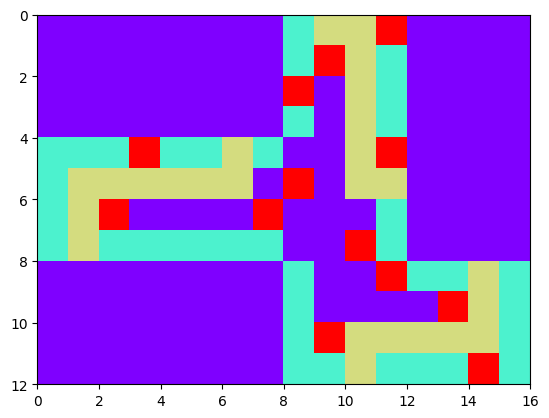

In [46]:
# TODO make the colors nicer, although it looks decent when using the non-example input file

# the evals are used to avoid parsing the string
maze_map_to_plot = maze_map.copy()
# maze_map_to_plot[:] *= 0
for wrap_point in wrap_points_correspondences_col_right.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_down.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_col_left.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for wrap_point in wrap_points_correspondences_row_up.keys():
    if( maze_map_to_plot[tuple(literal_eval(wrap_point))] ) == 0:
        maze_map_to_plot[tuple(literal_eval(wrap_point))] = 6

for blocked_cell in blocked_paths:
    maze_map_to_plot[tuple(blocked_cell)] = 15
    
plt.imshow(maze_map_to_plot, cmap="rainbow", extent=[0,n_cols,n_rows,0]); # it is more practical to use a imshow than to show text, as the input that is not from the example is really long. It would be nice to have the text file scaled and displayed

# [Day 23: Unstable Diffusion](https://adventofcode.com/2022/day/23)
**First Part:** Count the number of empty spaces after 10 rounds of the Elves moving

**Second Part:** Count the number of empty spaces after the Elves have stopped moving


In [47]:
ELF_CELL = "#"
N_ROUNDS = 10

class CardinalDirections(enum.IntEnum):
    NORTH = 0
    SOUTH = 1
    WEST = 2
    EAST = 3


with open(file_names[22]) as file:
    stacked_lines = file.read()
    lines22 = stacked_lines.splitlines()
    while(lines22[-1] == ""): # remove last empty lines, if any, they does not add information and can cause confusions
        lines22.pop()


elf_list = []
for row_idx, line in enumerate(lines22):
    for col_idx, cell_character in enumerate(line):
        if(cell_character == ELF_CELL):
            elf_list.append([row_idx,col_idx])

elf_positions = np.array(elf_list)

movement_direction_array = np.array([[[-1,-1],[-1,1],[-1,0]],[[1,-1],[1,1],[1,0]],[[-1,-1],[1,-1],[0,-1]],[[-1,1],[1,1],[0,1]]]) # ordered as north, south, west and east

n_elves = elf_positions.shape[0]

orientation_instructions = [CardinalDirections.NORTH, CardinalDirections.SOUTH, CardinalDirections.WEST, CardinalDirections.EAST]
for round_n in range(N_ROUNDS):

    # First phase
    positions_elves_able_to_move = elf_positions
    occupied_cells_mask = np.zeros(n_elves,dtype=bool)
    for extra_row in range(-1,2):
        for extra_col in range(-1,2):
            if(extra_col == 0 and extra_row == 0):
                continue

            cell_occupied_uppermask = (positions_elves_able_to_move + [extra_row,extra_col])[:,None] == elf_positions # create a mask used to check if every row of positions_elves_able_to_move is the same as a position in elf_positions
            occupied_cells_mask = np.sum(np.sum(cell_occupied_uppermask,axis=2) == 2, axis=1, dtype=bool) + occupied_cells_mask # extract the rows that already contain an elf position. The condition == 2 checks that both the row and the column of a row of the position array fulfill the condition
    
    positions_elves_able_to_move = positions_elves_able_to_move[occupied_cells_mask]
    if(positions_elves_able_to_move.size == 0):
        print("Elves cannot move anymore. The movement process stopped in round", round_n)
        break
    
    # Second phase
    n_movible_elves = positions_elves_able_to_move.shape[0]

    next_movement_array = np.zeros([n_movible_elves,2])
    uncompleted_movements_mask = np.ones(n_movible_elves,dtype=bool)

    not_allowed_planned_movements_mask = np.zeros(n_movible_elves,dtype=bool)
    unoccuppied_planned_movements_mask = np.ones(n_movible_elves,dtype=bool)
    
    next_considered_movement_array = next_movement_array.copy()
    positions_elves_able_to_move_considerated = positions_elves_able_to_move.copy() # not strictly necessary to copy
    not_allowed_considered_movements_mask = not_allowed_planned_movements_mask.copy() # not strictly necessary to copy
    unoccuppied_considered_movements_mask = unoccuppied_planned_movements_mask.copy() # not strictly necessary to copy

    for next_orientation in orientation_instructions:
        for movement_direction in movement_direction_array[next_orientation.value]:
            next_considered_movement_array[unoccuppied_considered_movements_mask] = movement_direction

            considered_movements = positions_elves_able_to_move_considerated + next_considered_movement_array
            occuppied_considered_movements_uppermask = considered_movements[:,None] == elf_positions
            not_allowed_considered_movements_mask = np.sum(np.sum(occuppied_considered_movements_uppermask,axis=2) == 2, axis=1, dtype=bool) + not_allowed_considered_movements_mask
            unoccuppied_considered_movements_mask = np.logical_not(not_allowed_considered_movements_mask)
        

        next_considered_movement_array[not_allowed_considered_movements_mask] = [0,0]
        next_movement_array[uncompleted_movements_mask == True] = next_considered_movement_array
        uncompleted_movements_mask[uncompleted_movements_mask == True] = not_allowed_considered_movements_mask

        considered_movements = next_movement_array + positions_elves_able_to_move
        occuppied_planned_movements_uppermask = considered_movements[:,None] == considered_movements
        occuppied_planned_movements_diagonalized = np.sum(occuppied_planned_movements_uppermask,axis=2)
        occuppied_planned_movements_undiagonalized = occuppied_planned_movements_diagonalized[~np.eye(occuppied_planned_movements_diagonalized.shape[0],dtype=bool)].reshape(occuppied_planned_movements_diagonalized.shape[0],-1) # remove diagonal so in the comparison they are not compared with themselves
        not_allowed_planned_movements_mask = np.sum(occuppied_planned_movements_undiagonalized == 2, axis=1, dtype=bool) + not_allowed_planned_movements_mask
        unoccuppied_planned_movements_mask = np.logical_not(not_allowed_planned_movements_mask)

        n_elves_still_to_move = np.sum(uncompleted_movements_mask)
        if(n_elves_still_to_move == 0):
            break

        next_considered_movement_array = next_movement_array[uncompleted_movements_mask == True]
        positions_elves_able_to_move_considerated = positions_elves_able_to_move[uncompleted_movements_mask == True]
        unoccuppied_considered_movements_mask = np.ones(n_elves_still_to_move, dtype=bool)
        not_allowed_considered_movements_mask = np.zeros(n_elves_still_to_move, dtype=bool)
        

    positions_elves_able_to_move[unoccuppied_planned_movements_mask] = considered_movements[unoccuppied_planned_movements_mask]
    elf_positions = np.vstack([elf_positions[np.logical_not(occupied_cells_mask)], positions_elves_able_to_move])

    orientation_instructions = orientation_instructions[1:] + [orientation_instructions[0]]

highest_occupied_row, highest_occupied_column = np.max(elf_positions,axis=0)
lowest_occupied_row, lowest_occupied_column = np.min(elf_positions,axis=0)

rectangle_height = np.abs(highest_occupied_row) + np.abs(lowest_occupied_row) + 1 
rectangle_width = np.abs(highest_occupied_column) + np.abs(lowest_occupied_column) + 1
n_empty_spaces = rectangle_height*rectangle_width - n_elves

# elf_positions[np.lexsort((elf_positions[:,1],elf_positions[:,0]))]
print("After", N_ROUNDS, "rounds, the smallest rectangle that contains all Elves has", n_empty_spaces, "emtpy spaces")

After 10 rounds, the smallest rectangle that contains all Elves has 110 emtpy spaces


In [48]:
ELF_CHARACTER_TO_PLOT = "#"
EMPTY_CELL_CHARACTER_TO_PLOT = "."

elf_positions_base0 = elf_positions.copy()
elf_positions_base0[:,0] = elf_positions_base0[:,0] + np.abs(lowest_occupied_row)
elf_positions_base0[:,1] = elf_positions_base0[:,1] + np.abs(lowest_occupied_column)

elf_map = np.zeros([rectangle_height,rectangle_width], dtype="str")
elf_map[elf_map == ""] = EMPTY_CELL_CHARACTER_TO_PLOT
for elf_position in elf_positions_base0:
    elf_map[(elf_position[0],elf_position[1])] = ELF_CHARACTER_TO_PLOT


for height_idx in range(rectangle_height):
    for width_idx in range(rectangle_width):
        print(elf_map[height_idx,width_idx], end = '')
    print("")

# # this plot scales even worst than the text plot
# elf_positions_base0_list = elf_positions_base0.tolist()
# plt.imshow(np.zeros([rectangle_height,rectangle_width]), cmap='binary')
# for row_idx in range(rectangle_height):
#     for col_idx in range(rectangle_width):
#         if([row_idx,col_idx] in elf_positions_base0_list):
#             character_to_print = ELF_CHARACTER_TO_PLOT
#         else:
#             character_to_print = EMPTY_CELL_CHARACTER_TO_PLOT
#         plt.text(col_idx, row_idx, character_to_print, fontsize=20, ha='center', va='center')


......#.....
..........#.
.#.#..#.....
.....#......
..#.....#..#
#......##...
....##......
.#........#.
...#.#..#...
............
...#..#..#..


In [49]:
'''
The following could is almost identical to the previous. The only different it has is that it loops infinitly (until all elves cannot move) instead of a fixed number of rounds. The code is really slow when using non-example data, taking about half an hour to complete. This is despite using numpy notation trying to avoid loops as much as possible. Further improvements could include excluding too far away elves when checking if their positions are occupied, as there is a tendency that only one group in the map moves

It has not been found yet a solution that can predict the final positions of the elves without computing every single movement of them. Although it may exists, there was no extrictly cyclical behaviour found
'''

elf_list = []
for row_idx, line in enumerate(lines22):
    for col_idx, cell_character in enumerate(line):
        if(cell_character == ELF_CELL):
            elf_list.append([row_idx,col_idx])

elf_positions = np.array(elf_list)

movement_direction_array = np.array([[[-1,-1],[-1,1],[-1,0]],[[1,-1],[1,1],[1,0]],[[-1,-1],[1,-1],[0,-1]],[[-1,1],[1,1],[0,1]]]) # ordered as north, south, west and east

n_elves = elf_positions.shape[0]

orientation_instructions = [CardinalDirections.NORTH, CardinalDirections.SOUTH, CardinalDirections.WEST, CardinalDirections.EAST]
round_n = 0
while(True):
    round_n +=1 # the number of rounds begins at 1

    # First phase
    positions_elves_able_to_move = elf_positions
    occupied_cells_mask = np.zeros(n_elves,dtype=bool)
    for extra_row in range(-1,2):
        for extra_col in range(-1,2):
            if(extra_col == 0 and extra_row == 0):
                continue

            cell_occupied_uppermask = (positions_elves_able_to_move + [extra_row,extra_col])[:,None] == elf_positions # create a mask used to check if every row of positions_elves_able_to_move is the same as a position in elf_positions
            occupied_cells_mask = np.sum(np.sum(cell_occupied_uppermask,axis=2) == 2, axis=1, dtype=bool) + occupied_cells_mask # extract the rows that already contain an elf position. The condition == 2 checks that both the row and the column of a row of the position array fulfill the condition
    
    positions_elves_able_to_move = positions_elves_able_to_move[occupied_cells_mask]
    if(positions_elves_able_to_move.size == 0):
        print("Elves cannot move anymore. The movement process stopped in round", round_n)
        break
    
    # Second phase
    n_movible_elves = positions_elves_able_to_move.shape[0]

    next_movement_array = np.zeros([n_movible_elves,2])
    uncompleted_movements_mask = np.ones(n_movible_elves,dtype=bool)

    not_allowed_planned_movements_mask = np.zeros(n_movible_elves,dtype=bool)
    unoccuppied_planned_movements_mask = np.ones(n_movible_elves,dtype=bool)
    
    next_considered_movement_array = next_movement_array.copy()
    positions_elves_able_to_move_considerated = positions_elves_able_to_move.copy() # not strictly necessary to copy
    not_allowed_considered_movements_mask = not_allowed_planned_movements_mask.copy() # not strictly necessary to copy
    unoccuppied_considered_movements_mask = unoccuppied_planned_movements_mask.copy() # not strictly necessary to copy

    for next_orientation in orientation_instructions:
        for movement_direction in movement_direction_array[next_orientation.value]:
            next_considered_movement_array[unoccuppied_considered_movements_mask] = movement_direction

            considered_movements = positions_elves_able_to_move_considerated + next_considered_movement_array
            occuppied_considered_movements_uppermask = considered_movements[:,None] == elf_positions
            not_allowed_considered_movements_mask = np.sum(np.sum(occuppied_considered_movements_uppermask,axis=2) == 2, axis=1, dtype=bool) + not_allowed_considered_movements_mask
            unoccuppied_considered_movements_mask = np.logical_not(not_allowed_considered_movements_mask)
        

        next_considered_movement_array[not_allowed_considered_movements_mask] = [0,0]
        next_movement_array[uncompleted_movements_mask == True] = next_considered_movement_array
        uncompleted_movements_mask[uncompleted_movements_mask == True] = not_allowed_considered_movements_mask

        considered_movements = next_movement_array + positions_elves_able_to_move
        occuppied_planned_movements_uppermask = considered_movements[:,None] == considered_movements
        occuppied_planned_movements_diagonalized = np.sum(occuppied_planned_movements_uppermask,axis=2)
        occuppied_planned_movements_undiagonalized = occuppied_planned_movements_diagonalized[~np.eye(occuppied_planned_movements_diagonalized.shape[0],dtype=bool)].reshape(occuppied_planned_movements_diagonalized.shape[0],-1) # remove diagonal so in the comparison they are not compared with themselves
        not_allowed_planned_movements_mask = np.sum(occuppied_planned_movements_undiagonalized == 2, axis=1, dtype=bool) + not_allowed_planned_movements_mask
        unoccuppied_planned_movements_mask = np.logical_not(not_allowed_planned_movements_mask)

        n_elves_still_to_move = np.sum(uncompleted_movements_mask)
        if(n_elves_still_to_move == 0):
            break

        next_considered_movement_array = next_movement_array[uncompleted_movements_mask == True]
        positions_elves_able_to_move_considerated = positions_elves_able_to_move[uncompleted_movements_mask == True]
        unoccuppied_considered_movements_mask = np.ones(n_elves_still_to_move, dtype=bool)
        not_allowed_considered_movements_mask = np.zeros(n_elves_still_to_move, dtype=bool)
        

    positions_elves_able_to_move[unoccuppied_planned_movements_mask] = considered_movements[unoccuppied_planned_movements_mask]
    elf_positions = np.vstack([elf_positions[np.logical_not(occupied_cells_mask)], positions_elves_able_to_move])

    orientation_instructions = orientation_instructions[1:] + [orientation_instructions[0]]

highest_occupied_row, highest_occupied_column = np.max(elf_positions,axis=0)
lowest_occupied_row, lowest_occupied_column = np.min(elf_positions,axis=0)

rectangle_height = np.abs(highest_occupied_row) + np.abs(lowest_occupied_row) + 1 
rectangle_width = np.abs(highest_occupied_column) + np.abs(lowest_occupied_column) + 1
n_empty_spaces = rectangle_height*rectangle_width - n_elves


print("The smallest rectangle that contains all Elves has", n_empty_spaces, "emtpy spaces") # not actually necessary anymore for this part

Elves cannot move anymore. The movement process stopped in round 20
The smallest rectangle that contains all Elves has 146 emtpy spaces


# [Day 24: Blizzard Basin](https://adventofcode.com/2022/day/24)
**First Part:** TODO

**Second Part:** TODO


# [Day 25: Full of Hot Air](https://adventofcode.com/2022/day/25)
**First Part:** Add numbers together, taking into account that these are in another numbering system (called SNAFU)

**Second Part:** TBA


In [50]:
MINUS_SIGN = "-"
DOUBLE_MINUS_SIGN = "="
SNAFU_RADIX = 5

def SNAFUToDecimal(SNAFU_number):
    decimal_number = 0
    for digit_place, snafu_digit_char in enumerate(SNAFU_number[::-1]):

        if snafu_digit_char == MINUS_SIGN:
            snafu_digit = -1
        elif(snafu_digit_char == DOUBLE_MINUS_SIGN):
            snafu_digit = -2
        else:
            snafu_digit = int(snafu_digit_char)

        decimal_number += snafu_digit * SNAFU_RADIX**digit_place

    return decimal_number


def DecimalToSNAFU(decimal_number):
    radixed_number = ""
    floored_fraction = decimal_number
    while(floored_fraction != 0):
        floored_fraction, remainder = divmod(floored_fraction,SNAFU_RADIX)
        radixed_number += str(remainder)
    
    radixed_number = radixed_number[::-1]

    SNAFU_number_list = list(radixed_number)
    carried_value = 0
    for idx in reversed(range(len(radixed_number))):
        radixed_digit = int(radixed_number[idx])
        if (carried_value == 1):
            radixed_digit +=1 
            carried_value = 0
        
        if(radixed_digit == 4):
            SNAFU_number_list[idx] = "-"
            carried_value = 1
        elif(radixed_digit == 3):
            SNAFU_number_list[idx] = "="
            carried_value = 1
        else:
            SNAFU_number_list[idx] = str(radixed_digit)

    if(carried_value==1):
        SNAFU_number = "1" + SNAFU_number

    SNAFU_number = "".join(SNAFU_number_list)
    return SNAFU_number


with open(file_names[24]) as file:
    stacked_lines = file.read()
    lines22 = stacked_lines.splitlines()
    while(lines22[-1] == ""): # remove last empty line, if any, to avoid adding an extra "if" in the following loop
        lines22.pop()


number_sum_decimal = 0
for line in lines22:
    number_sum_decimal += SNAFUToDecimal(line)


number_sum_SNAFU = DecimalToSNAFU(number_sum_decimal)


print("The sum of decimal numbers is {}, which is equivalent to {} when using SNAFU (radix {})".format(number_sum_decimal, number_sum_SNAFU, SNAFU_RADIX))

The sum of decimal numbers is 4890, which is equivalent to 2=-1=0 when using SNAFU (radix 5)
